# Laboratorio 4 - Árboles de Decisión
### Mineria de datos

#### Importación de librerías

In [1]:
%pip install numpy pandas matplotlib seaborn scipy pyreadr scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pyreadr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler



### 1: Carga del conjunto de datos

Se utiliza el módulo `pyreadr` para cargar el archivo `.Rdata` que contiene los listings de Airbnb.
Este módulo permite leer archivos nativos de R directamente en Python como DataFrames de pandas.

In [3]:
# cargar el archivo .Rdata con pyreadr
resultado = pyreadr.read_r('data/listings.Rdata')

In [4]:
# extraer el dataframe principal (ajustar el nombre de la clave segun lo que imprima la celda anterior)
df = resultado[list(resultado.keys())[0]]

print('Dimensiones del dataset:', df.shape)

# vista rapida de las primeras filas
df.head(3)

Dimensiones del dataset: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


### 2: Análisis Exploratorio de Datos (EDA)

El objetivo es predecir el **precio por noche** (`price`) de las propiedades. El EDA nos ayuda a entender la distribución de los datos, identificar valores atípicos, relaciones entre variables y decidir qué preprocesamiento se necesita.

#### 2.1 Resumen general del dataset

In [5]:
# estadisticas descriptivas de las variables numericas
df.describe()

,id,scrape_id,host_id,latitude,longitude,accommodates,bathrooms,minimum_nights,maximum_nights,minimum_nights_avg_ntm,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,1.717480e+05,1.717480e+05,1.717480e+05,171748.000000,171748.000000,171748.000000,140352.000000,171748.000000,1.717480e+05,171748.000000,...,131446.000000,131424.000000,131440.000000,131420.000000,131420.000000,171748.000000,171748.000000,171748.000000,171748.000000,131461.000000
mean,6.362915e+17,2.025107e+13,2.002571e+08,33.776320,-109.489530,4.106796,1.551795,16.996559,1.298827e+04,17.487677,...,4.752217,4.859050,4.852813,4.804140,4.690129,45.879987,39.608950,5.539005,0.082114,1.344455
std,5.834928e+17,1.419625e+08,2.048830e+08,7.236441,30.024424,2.836661,1.014407,30.014597,5.181840e+06,30.788964,...,0.411183,0.335401,0.358002,0.344275,0.428966,135.161293,131.065101,37.500862,1.643607,1.788745
min,6.000000e+00,2.025092e+13,2.300000e+01,18.989648,-159.716528,1.000000,0.000000,1.000000,1.000000e+00,0.700000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.599300e+07,2.025092e+13,2.633063e+07,30.381088,-118.591115,2.000000,1.000000,2.000000,9.000000e+01,2.000000,...,4.690000,4.860000,4.860000,4.750000,4.620000,1.000000,1.000000,0.000000,0.000000,0.190000
50%,7.249557e+17,2.025120e+13,1.080585e+08,34.089840,-117.865347,4.000000,1.000000,4.000000,3.650000e+02,4.400000,...,4.880000,4.960000,4.960000,4.910000,4.800000,3.000000,1.000000,0.000000,0.000000,0.700000
75%,1.182638e+18,2.025120e+13,3.765745e+08,40.702460,-73.997148,6.000000,2.000000,30.000000,1.125000e+03,30.000000,...,5.000000,5.000000,5.000000,5.000000,4.920000,21.000000,12.000000,1.000000,0.000000,2.000000
max,1.567804e+18,2.025120e+13,7.320923e+08,42.391844,-70.996000,16.000000,32.500000,1125.000000,2.147484e+09,1125.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,1189.000000,1189.000000,567.000000,60.000000,120.370000


In [6]:
# conteo de valores nulos por columna
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df)) * 100
resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje': nulos_pct})
resumen_nulos = resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('porcentaje', ascending=False)
resumen_nulos

,nulos,porcentaje
calendar_updated,171748,100.000000
estimated_revenue_l365d,95502,55.605888
price,89381,52.041945
neighbourhood_group_cleansed,50683,29.510096
review_scores_value,40328,23.480914
review_scores_location,40328,23.480914
review_scores_checkin,40324,23.478585
review_scores_accuracy,40312,23.471598
review_scores_communication,40308,23.469269
review_scores_cleanliness,40302,23.465775


**Hallazgo:** Las columnas con más del 30% de valores nulos no aportan valor predictivo confiable y serán eliminadas o imputadas según corresponda. Las columnas de texto libre como `description` y `neighborhood_overview` tampoco se usarán directamente en el modelo.

#### 2.2 Preprocesamiento de la variable price

In [7]:
# revisar el formato actual del precio (puede venir como string con $)
df['price'].head(10)

0     $97.00
1    $160.00
2     $38.00
3    $145.00
4     $58.00
5     $49.00
6    $300.00
7    $150.00
8    $165.00
9    $117.00
Name: price, dtype: object

In [8]:
# Limpiar la columna price (quitar $ y comas, convertir a número)
df['price'] = (
    df['price']
    .astype(str)  # asegurar que todo sea string
    .str.replace(r'[$,]', '', regex=True)
)

# Convertir a float (los errores se vuelven NaN)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Eliminar valores nulos o inválidos
df = df[df['price'].notna()]
df = df[df['price'] > 0]

# Mostrar resultados
print(df.shape)
df['price'].describe()

(76246, 80)


count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64

#### 2.3 Distribución de la variable respuesta: price

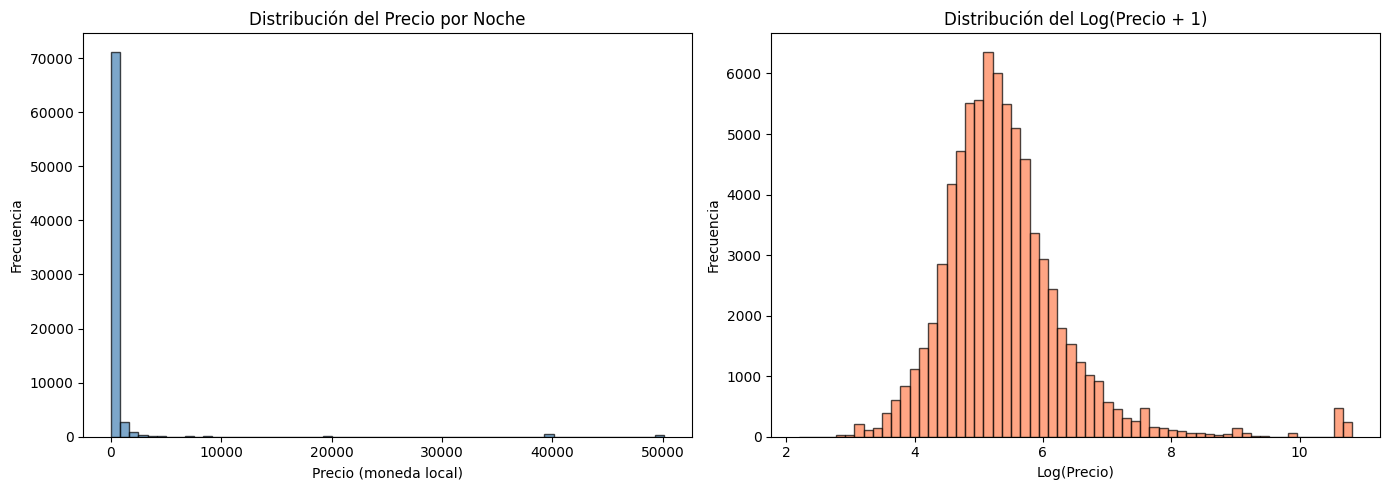

In [9]:
# histograma del precio original
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=60, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribución del Precio por Noche')
plt.xlabel('Precio (moneda local)')
plt.ylabel('Frecuencia')

# histograma con transformacion logaritmica para ver mejor la distribucion
plt.subplot(1, 2, 2)
plt.hist(np.log1p(df['price']), bins=60, color='coral', edgecolor='black', alpha=0.7)
plt.title('Distribución del Log(Precio + 1)')
plt.xlabel('Log(Precio)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Hallazgo:**  La variable precio presenta una fuerte asimetría positiva, con una cola larga hacia valores altos, lo que indica la presencia de outliers y una distribución no normal. Al aplicar una transformación logarítmica, la distribución se vuelve más simétrica y cercana a una forma normal, lo que sugiere que el precio sigue aproximadamente una distribución log-normal. Esta transformación es útil para modelos de regresión lineal, ya que ayuda a cumplir mejor sus supuestos. En contraste, modelos basados en árboles no requieren normalidad, por lo que son menos sensibles a esta asimetría.

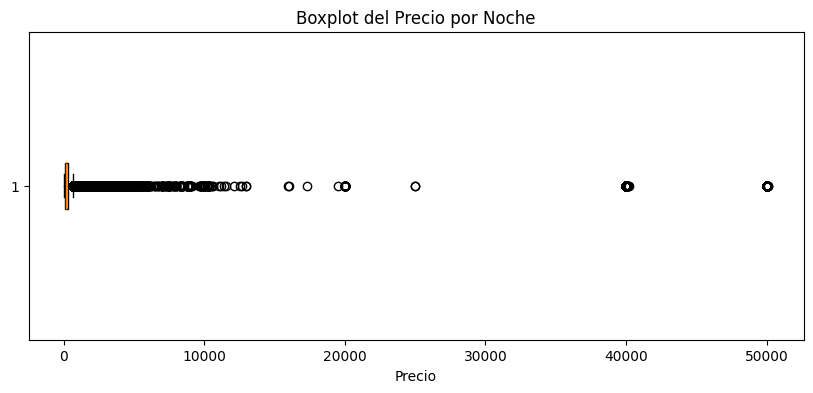

P25: 120.00 | Mediana: 193.00 | P75: 326.00 | P95: 1034.00 | P99: 20000.00


In [10]:
# boxplot para visualizar outliers en el precio
plt.figure(figsize=(10, 4))
plt.boxplot(df['price'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.title('Boxplot del Precio por Noche')
plt.xlabel('Precio')
plt.show()

# calcular percentiles para entender los extremos
p25 = df['price'].quantile(0.25)
p50 = df['price'].quantile(0.50)
p75 = df['price'].quantile(0.75)
p95 = df['price'].quantile(0.95)
p99 = df['price'].quantile(0.99)
print(f'P25: {p25:.2f} | Mediana: {p50:.2f} | P75: {p75:.2f} | P95: {p95:.2f} | P99: {p99:.2f}')

**Hallazgo:** Existen valores extremos (outliers) de precio. Los valores en el percentil 99 pueden representar propiedades de lujo atípicas que podrían distorsionar el modelo. Se optará por filtrar precios por encima del percentil 99 para evitar que estos casos extremos afecten el entrenamiento.

In [11]:
# filtrar outliers extremos de precio (por encima del percentil 99)
limite_superior = df['price'].quantile(0.99)
df = df[df['price'] <= limite_superior]
print(f'Filas despues de eliminar outliers extremos de precio: {df.shape[0]}')
print(f'Rango de precio resultante: {df["price"].min():.2f} - {df["price"].max():.2f}')

Filas despues de eliminar outliers extremos de precio: 75531
Rango de precio resultante: 8.00 - 20000.00


#### 2.4 Variables numéricas: distribución y correlación con el precio

In [12]:
# seleccionar variables numericas relevantes para el modelo
vars_numericas = [
    'price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'minimum_nights', 'maximum_nights', 'number_of_reviews',
    'review_scores_rating', 'review_scores_cleanliness',
    'review_scores_location', 'review_scores_value',
    'reviews_per_month', 'calculated_host_listings_count',
    'availability_365'
]

# filtrar solo las que existen en el dataframe
vars_numericas = [v for v in vars_numericas if v in df.columns]
df_num = df[vars_numericas].copy()

# estadisticas descriptivas de las variables seleccionadas
df_num.describe().round(2)

,price,accommodates,bathrooms,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,review_scores_cleanliness,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,availability_365
count,75531.00,75531.00,75517.00,75531.00,75531.00,75531.00,62664.00,62660.00,62660.00,62660.00,62664.00,75531.00,75531.00
mean,347.94,4.83,1.62,9.49,469.80,54.94,4.80,4.79,4.84,4.71,1.58,54.22,231.39
std,854.85,2.98,0.98,22.48,417.23,97.03,0.33,0.33,0.28,0.36,1.73,113.34,106.57
min,8.00,1.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,0.01,1.00,0.00
25%,119.00,2.00,1.00,1.00,90.00,2.00,4.75,4.73,4.80,4.64,0.33,1.00,152.00
50%,191.00,4.00,1.00,2.00,365.00,16.00,4.89,4.88,4.92,4.79,1.03,5.00,256.00
75%,320.00,6.00,2.00,5.00,1125.00,65.00,5.00,5.00,5.00,4.91,2.36,40.00,326.00
max,20000.00,16.00,20.00,720.00,3650.00,1592.00,5.00,5.00,5.00,5.00,61.59,612.00,365.00


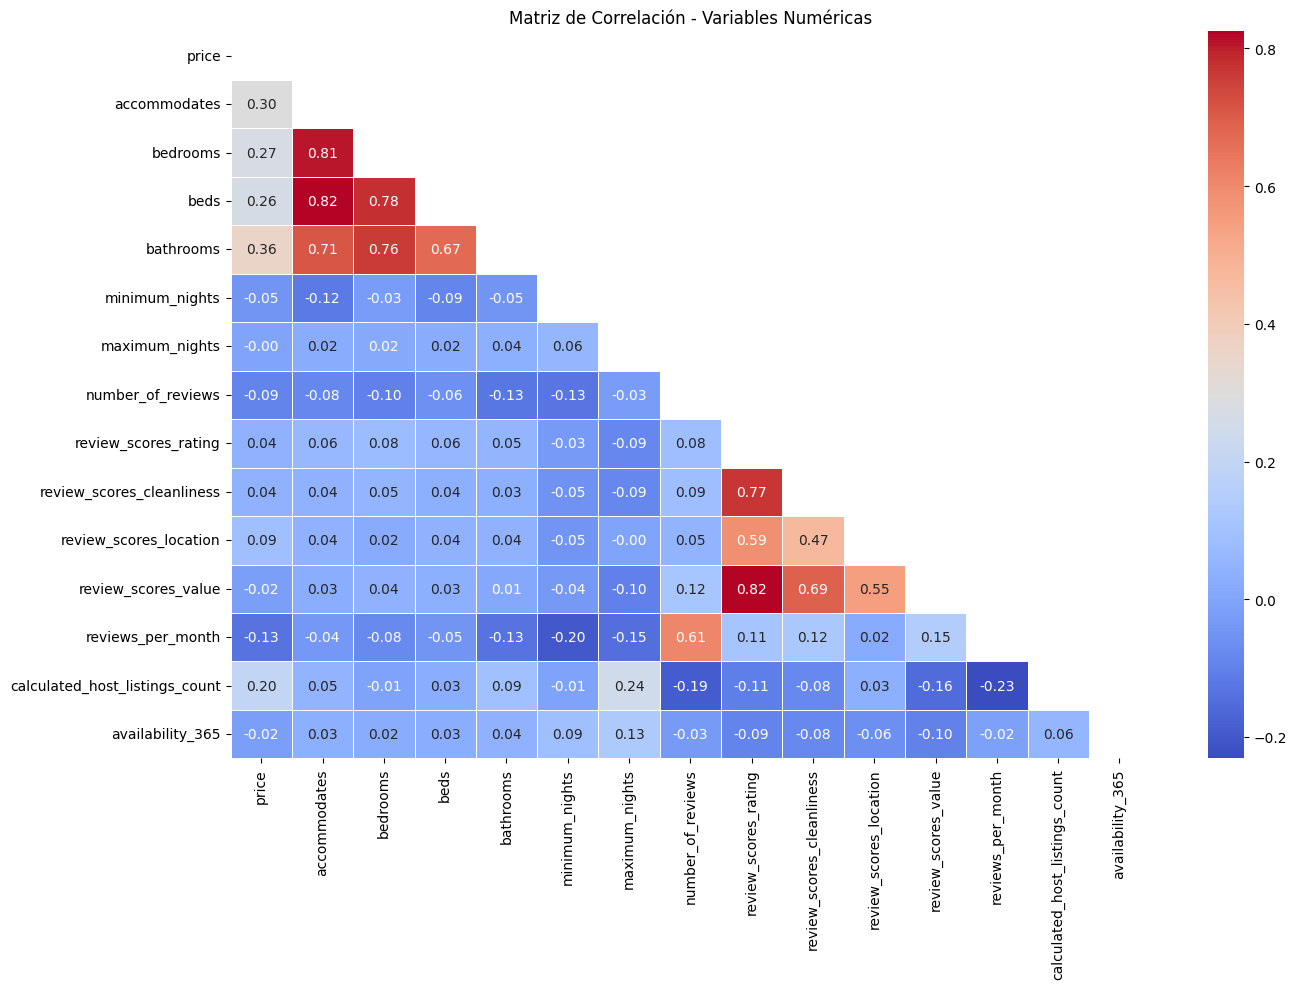

In [13]:
# matriz de correlacion de las variables numericas
plt.figure(figsize=(14, 10))
corr_matrix = df_num.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.tight_layout()
plt.show()

**Hallazgo:** Las variables como bathrooms, accommodates, bedrooms y beds, presentan las correlaciones positivas más altas con el precio, lo que indica que propiedades más grandes y con mayor capacidad tienden a ser más costosas. Sin embargo, estas variables están altamente correlacionadas entre sí, lo que sugiere la presencia de multicolinealidad. Por otro lado, las variables de calificación de reseñas muestran correlaciones débiles con el precio, indicando que la calidad percibida no tiene una relación lineal fuerte con el costo.

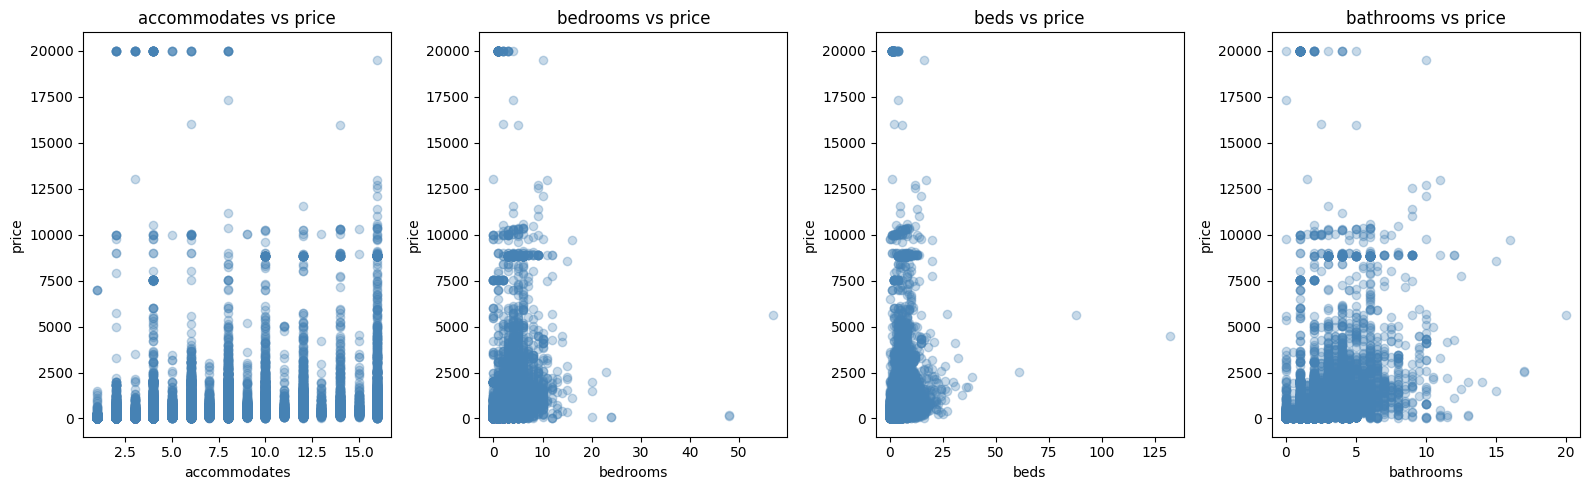

In [14]:
# scatter plots de las variables mas correlacionadas con price
top_vars = ['accommodates', 'bedrooms', 'beds', 'bathrooms']
top_vars = [v for v in top_vars if v in df.columns]

fig, axes = plt.subplots(1, len(top_vars), figsize=(16, 5))
for i, var in enumerate(top_vars):
    axes[i].scatter(df[var], df['price'], alpha=0.3, color='steelblue')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('price')
    axes[i].set_title(f'{var} vs price')

plt.tight_layout()
plt.show()

**Hallazgo:** Existe una tendencia positiva entre la cantidad de personas que puede alojar la propiedad (accommodates) y el precio: en general, a mayor capacidad, mayor precio. Sin embargo, la relación no es muy fuerte, ya que para una misma capacidad los precios pueden variar bastante. Además, a medida que aumenta la capacidad, también aumenta la variación de los precios, lo que indica que hay otros factores importantes que influyen en el valor final.

#### 2.5 Variables categóricas relevantes

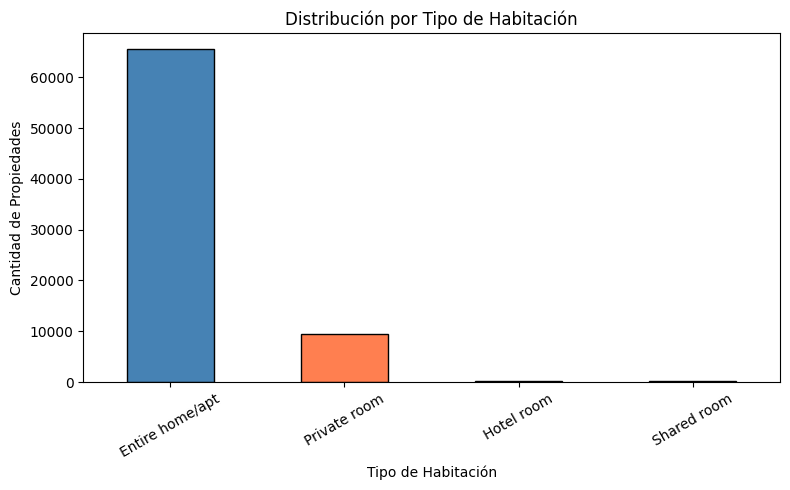

room_type
Entire home/apt    65479
Private room        9547
Hotel room           290
Shared room          215
Name: count, dtype: int64


In [15]:
# distribucion del tipo de habitacion
if 'room_type' in df.columns:
    conteo_room = df['room_type'].value_counts()
    plt.figure(figsize=(8, 5))
    conteo_room.plot(kind='bar', color=['steelblue', 'coral', 'green', 'orange'], edgecolor='black')
    plt.title('Distribución por Tipo de Habitación')
    plt.xlabel('Tipo de Habitación')
    plt.ylabel('Cantidad de Propiedades')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    print(conteo_room)

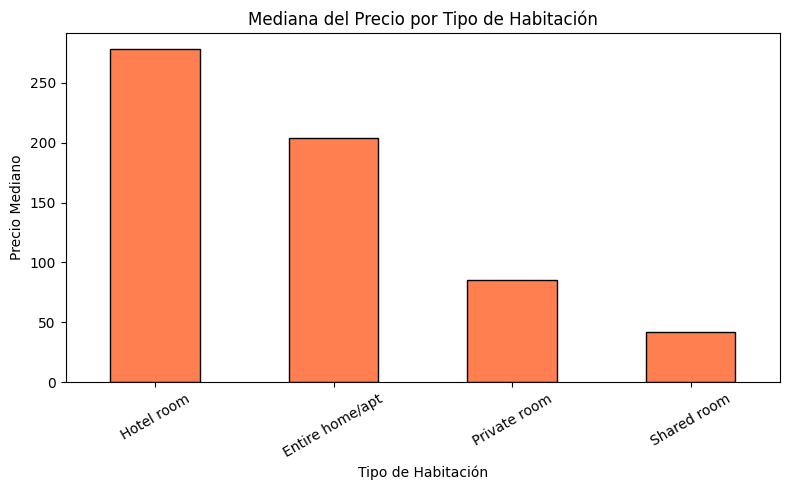

room_type
Hotel room         278.0
Entire home/apt    204.0
Private room        85.0
Shared room         42.0
Name: price, dtype: float64


In [16]:
# precio promedio por tipo de habitacion
if 'room_type' in df.columns:
    precio_por_tipo = df.groupby('room_type')['price'].median().sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    precio_por_tipo.plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Mediana del Precio por Tipo de Habitación')
    plt.xlabel('Tipo de Habitación')
    plt.ylabel('Precio Mediano')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    print(precio_por_tipo)

**Hallazgo:** Los alojamientos completos (`Entire home/apt`) tienen precios medianos significativamente más altos que las habitaciones privadas o compartidas. Esta variable será muy relevante para el modelo de predicción de precios.

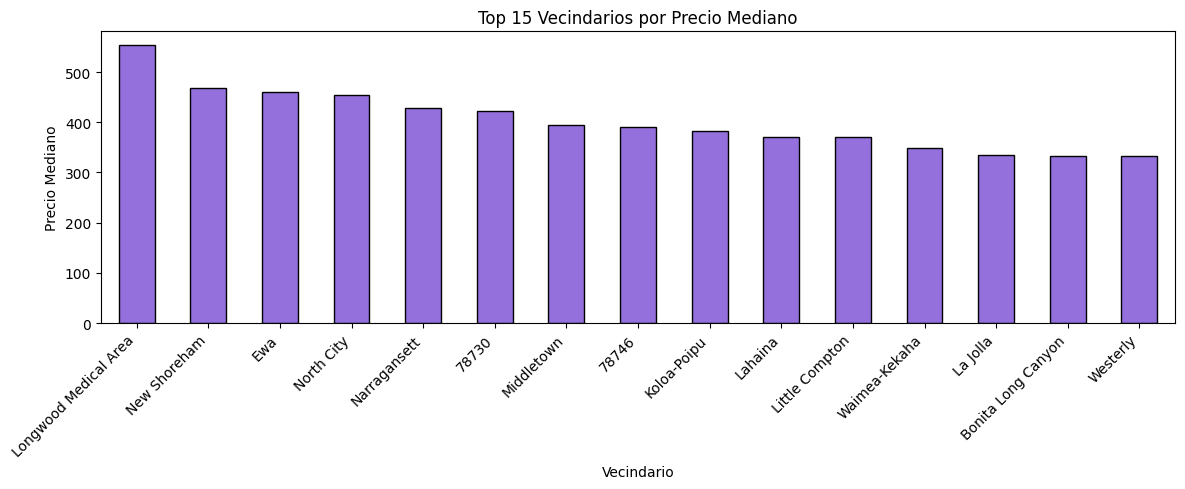

In [17]:
# precio promedio por vecindario (top 15)
if 'neighbourhood_cleansed' in df.columns:
    precio_vecindario = df.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False).head(15)
    plt.figure(figsize=(12, 5))
    precio_vecindario.plot(kind='bar', color='mediumpurple', edgecolor='black')
    plt.title('Top 15 Vecindarios por Precio Mediano')
    plt.xlabel('Vecindario')
    plt.ylabel('Precio Mediano')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**Hallazgo:** La ubicación (vecindario) tiene un impacto considerable en el precio. Existen vecindarios con precios medianos notablemente más altos, lo que indica que la variable `neighbourhood_cleansed` tiene poder predictivo importante y debe incluirse en el modelo.

#### 2.6 Test de normalidad en la variable price

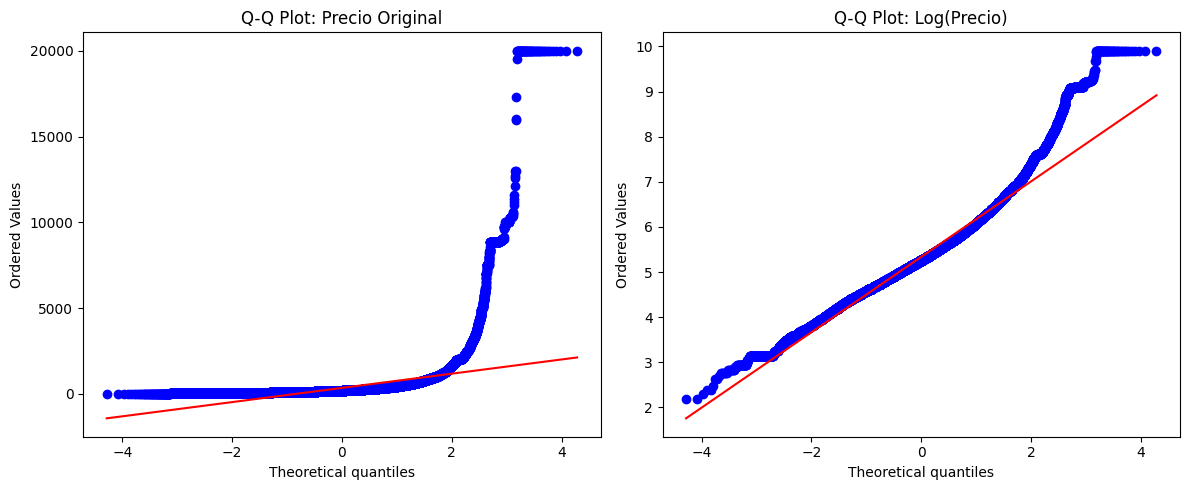

In [18]:
# Q-Q plot para evaluar normalidad del precio
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(df['price'], dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: Precio Original')

stats.probplot(np.log1p(df['price']), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Log(Precio)')

plt.tight_layout()
plt.show()

In [19]:
# test de normalidad Shapiro-Wilk (se usa una muestra por limitaciones de tamaño)
muestra = df['price'].sample(min(5000, len(df)), random_state=42)
stat, p_valor = stats.shapiro(muestra)
print(f'Shapiro-Wilk sobre precio: estadistico={stat:.4f}, p-valor={p_valor:.6f}')
if p_valor < 0.05:
    print('El precio NO sigue una distribucion normal (p < 0.05)')
else:
    print('No se rechaza normalidad (p >= 0.05)')

Shapiro-Wilk sobre precio: estadistico=0.2465, p-valor=0.000000
El precio NO sigue una distribucion normal (p < 0.05)


**Hallazgo:** El precio no sigue una distribución normal. El Q-Q plot muestra desviaciones en los extremos, confirmando la asimetría observada en el histograma. Para los árboles de decisión esto no es un problema, ya que no asumen ninguna distribución específica en los datos.

#### 2.7 Preprocesamiento final del dataset

In [20]:
# seleccionar columnas utiles para el modelo (descartando URLs, IDs, texto libre y fechas)
columnas_modelo = [
    'price',
    'room_type',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'maximum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'availability_365',
    'calculated_host_listings_count',
    'host_is_superhost',
    'neighbourhood_cleansed',
    'instant_bookable'
]

# filtrar solo las columnas que existen en el dataset
columnas_modelo = [c for c in columnas_modelo if c in df.columns]
df_modelo = df[columnas_modelo].copy()

print('Columnas seleccionadas para el modelo:')
print(columnas_modelo)
print('\nDimensiones:', df_modelo.shape)

Columnas seleccionadas para el modelo:
['price', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'host_is_superhost', 'neighbourhood_cleansed', 'instant_bookable']

Dimensiones: (75531, 21)


In [21]:
# imputar valores nulos en numericas con la mediana
cols_numericas_modelo = df_modelo.select_dtypes(include=[np.number]).columns.tolist()
cols_numericas_modelo = [c for c in cols_numericas_modelo if c != 'price']

for col in cols_numericas_modelo:
    mediana = df_modelo[col].median()
    nulos_col = df_modelo[col].isnull().sum()
    if nulos_col > 0:
        df_modelo[col] = df_modelo[col].fillna(mediana)
        print(f'{col}: {nulos_col} nulos imputados con mediana={mediana:.2f}')

# imputar variables categoricas con el valor mas frecuente
cols_cat_modelo = df_modelo.select_dtypes(include='object').columns.tolist()

for col in cols_cat_modelo:
    nulos_col = df_modelo[col].isnull().sum()
    if nulos_col > 0:
        moda = df_modelo[col].mode()[0]
        df_modelo[col] = df_modelo[col].fillna(moda)
        print(f'{col}: {nulos_col} nulos imputados con moda={moda}')

print('\nNulos restantes:', df_modelo.isnull().sum().sum())

bathrooms: 14 nulos imputados con mediana=1.00
review_scores_rating: 12867 nulos imputados con mediana=4.89
review_scores_cleanliness: 12871 nulos imputados con mediana=4.88
review_scores_checkin: 12871 nulos imputados con mediana=4.95
review_scores_communication: 12871 nulos imputados con mediana=4.96
review_scores_location: 12871 nulos imputados con mediana=4.92
review_scores_value: 12871 nulos imputados con mediana=4.79
reviews_per_month: 12867 nulos imputados con mediana=1.03
bedrooms: 121 nulos imputados con moda=1
beds: 80 nulos imputados con moda=1

Nulos restantes: 0


C:\Users\jlope\AppData\Local\Temp\ipykernel_35536\2183229223.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_modelo[col] = df_modelo[col].fillna(moda)


In [22]:
# convertir variables booleanas/categoricas a numericas usando Label Encoding
# esto es necesario para los modelos de sklearn
le = LabelEncoder()

cols_a_codificar = df_modelo.select_dtypes(include=['object', 'bool']).columns.tolist()
print('Columnas a codificar:', cols_a_codificar)

df_procesado = df_modelo.copy()
for col in cols_a_codificar:
    df_procesado[col] = le.fit_transform(df_procesado[col].astype(str))

print('\nTipos de datos despues de codificacion:')
print(df_procesado.dtypes)

Columnas a codificar: ['room_type', 'host_is_superhost', 'neighbourhood_cleansed', 'instant_bookable']

Tipos de datos despues de codificacion:
price                             float64
room_type                           int64
accommodates                        int32
bathrooms                         float64
bedrooms                            int64
beds                                int64
minimum_nights                      int32
maximum_nights                      int32
number_of_reviews                   int32
review_scores_rating              float64
review_scores_cleanliness         float64
review_scores_checkin             float64
review_scores_communication       float64
review_scores_location            float64
review_scores_value               float64
reviews_per_month                 float64
availability_365                    int32
calculated_host_listings_count      int32
host_is_superhost                   int64
neighbourhood_cleansed              int64
instant_bookable

In [23]:
# verificacion final del dataframe procesado
print('Forma final del dataframe para modelado:', df_procesado.shape)
print('Nulos restantes:', df_procesado.isnull().sum().sum())
df_procesado.head()

Forma final del dataframe para modelado: (75531, 21)
Nulos restantes: 0


,price,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,number_of_reviews,review_scores_rating,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,availability_365,calculated_host_listings_count,host_is_superhost,neighbourhood_cleansed,instant_bookable
0,97.0,0,3,1.0,1,2,2,90,708,4.85,...,4.90,4.82,4.73,4.79,3.52,328,1,2,1,0
1,160.0,0,2,1.0,1,2,3,365,339,4.97,...,4.99,4.98,4.97,4.88,1.98,316,1,2,3,1
2,38.0,0,2,1.0,1,1,4,90,54,4.57,...,4.85,4.88,4.69,4.63,0.28,88,1,1,26,0
3,145.0,0,3,2.0,2,2,15,150,19,5.00,...,5.00,5.00,5.00,4.95,0.11,321,2,2,1,0
4,58.0,0,2,1.0,1,1,30,365,56,4.95,...,5.00,5.00,4.72,4.84,0.30,211,1,2,26,0


### Actividad 3: Análisis de Grupos (Clustering)

Se aplica K-Means sobre variables clave para identificar grupos naturales de propiedades. Esto ayuda a entender si existen segmentos diferenciados en el mercado que puedan explicar los distintos niveles de precio.

In [24]:
# seleccionar variables para el clustering
vars_cluster = ['price', 'accommodates', 'bedrooms', 'review_scores_rating', 'availability_365']
vars_cluster = [v for v in vars_cluster if v in df_procesado.columns]

df_cluster = df_procesado[vars_cluster].dropna().copy()

# estandarizar las variables (necesario para K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
print('Datos para clustering:', X_scaled.shape)

Datos para clustering: (75531, 5)


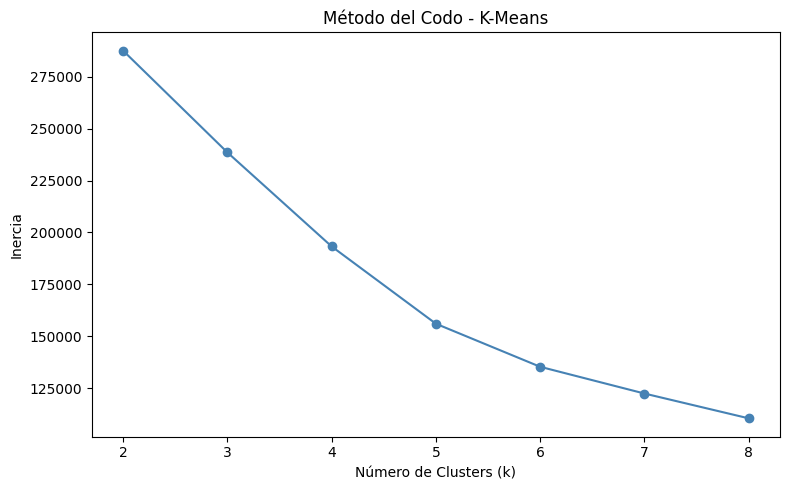

In [25]:
# metodo del codo para elegir el numero optimo de clusters
inercias = []
k_valores = range(2, 9)

for k in k_valores:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_valores, inercias, marker='o', color='steelblue')
plt.title('Método del Codo - K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(k_valores)
plt.tight_layout()
plt.show()

**Hallazgo:** El método del codo sugiere que el número óptimo de clusters es 3 o 4, ya que a partir de ese punto la reducción de inercia disminuye significativamente. Usaremos k=3 ya que coincide conceptualmente con las categorías que queremos predecir (Económica, Intermedia, Cara).

In [26]:
# aplicar K-Means con k=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans_final.fit_predict(X_scaled)

# resumen de cada cluster
resumen_clusters = df_cluster.groupby('cluster').mean().round(2)
tamano_clusters = df_cluster['cluster'].value_counts().sort_index()

from IPython.display import display

display(resumen_clusters)
display(tamano_clusters)

,price,accommodates,bedrooms,review_scores_rating,availability_365
cluster,,,,,
0,228.86,3.94,1.45,4.86,105.55
1,226.25,3.83,1.38,4.78,300.70
2,1017.13,10.13,4.04,4.86,248.55


cluster
0    23743
1    40244
2    11544
Name: count, dtype: int64

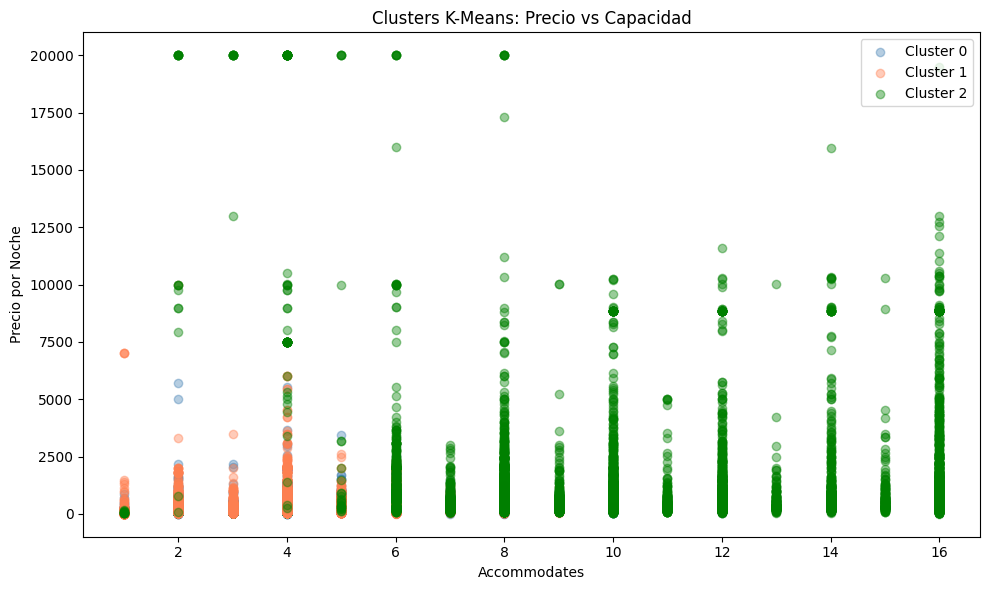

In [27]:
# visualizacion de clusters: precio vs accommodates
colores = ['steelblue', 'coral', 'green']
plt.figure(figsize=(10, 6))
for i in range(3):
    grupo = df_cluster[df_cluster['cluster'] == i]
    plt.scatter(grupo['accommodates'], grupo['price'],
                alpha=0.4, color=colores[i], label=f'Cluster {i}')
plt.title('Clusters K-Means: Precio vs Capacidad')
plt.xlabel('Accommodates')
plt.ylabel('Precio por Noche')
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

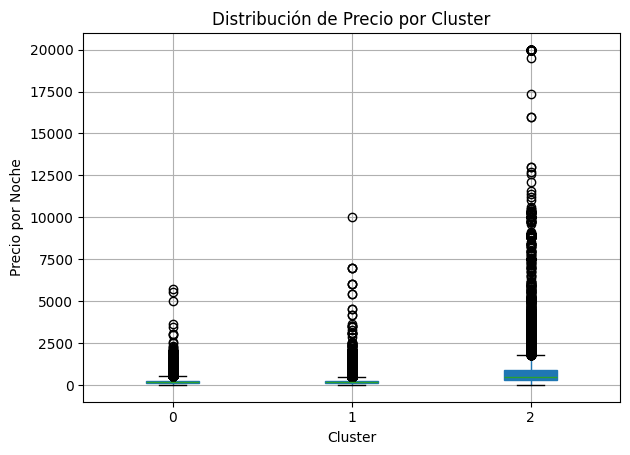

In [28]:
# boxplot de precio por cluster
plt.figure(figsize=(8, 5))
df_cluster.boxplot(column='price', by='cluster',
                   patch_artist=True, notch=False)
plt.suptitle('')
plt.title('Distribución de Precio por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Precio por Noche')
plt.tight_layout()
plt.show()

**Interpretación de los clusters:**

- **Cluster 0 (Económico):** Propiedades de bajo precio, menor capacidad y menos habitaciones. Representan alojamientos más accesibles, probablemente habitaciones privadas o compartidas.
- **Cluster 1 (Intermedio):** Propiedades con precios moderados y mayor capacidad de alojamiento. Constituyen la mayor parte del mercado y corresponden a opciones estándar.
- **Cluster 2 (Atípico):** Grupo muy reducido de propiedades con precios extremadamente altos y características poco comunes. Este cluster parece representar valores atípicos más que un segmento natural del mercado.

Esta segmentación muestra que el mercado se divide principalmente en dos grupos claros (económico e intermedio), mientras que el tercer cluster está dominado por observaciones extremas.

### Actividad 4: División en conjuntos de Entrenamiento y Prueba

Se divide el dataset procesado en dos subconjuntos: 70% para entrenamiento y 30% para prueba. La división usa la variable `room_type` codificada para garantizar que la proporción de cada tipo de propiedad sea similar en ambos conjuntos.

In [29]:
# separar variable respuesta (price) de las variables predictoras
y = df_procesado['price']
X = df_procesado.drop(columns=['price'])

print('Variable respuesta (y):', y.shape)
print('Variables predictoras (X):', X.shape)
print('\nColumnas en X:', list(X.columns))

Variable respuesta (y): (75531,)
Variables predictoras (X): (75531, 20)

Columnas en X: ['room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'host_is_superhost', 'neighbourhood_cleansed', 'instant_bookable']


In [30]:
# division estratificada 70/30 usando room_type como variable de estratificacion
# se estratifica para mantener la proporcion de tipos de habitacion en ambos conjuntos
estrato = None
if 'room_type' in X.columns:
    estrato = X['room_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    train_size=0.70,
    stratify=estrato,
    random_state=42
)

print('Conjunto de entrenamiento (X_train):', X_train.shape)
print('Conjunto de prueba     (X_test): ', X_test.shape)
print('Labels entrenamiento   (y_train):', y_train.shape)
print('Labels prueba          (y_test): ', y_test.shape)

Conjunto de entrenamiento (X_train): (52871, 20)
Conjunto de prueba     (X_test):  (22660, 20)
Labels entrenamiento   (y_train): (52871,)
Labels prueba          (y_test):  (22660,)


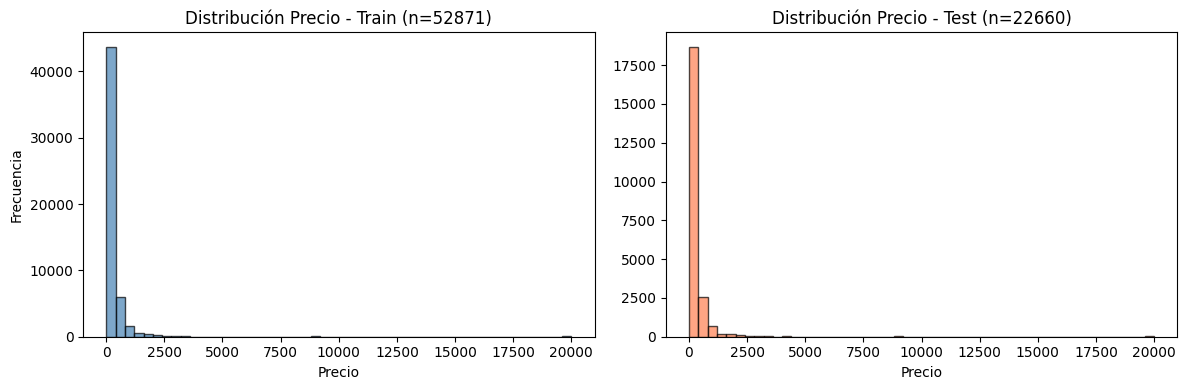

Media precio train: 344.46 | Media precio test: 356.07
Mediana precio train: 191.00 | Mediana precio test: 191.00


In [31]:
# verificar que la distribucion de precios es similar en train y test
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Distribución Precio - Train (n={len(y_train)})')
axes[0].set_xlabel('Precio')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(y_test, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Distribución Precio - Test (n={len(y_test)})')
axes[1].set_xlabel('Precio')

plt.tight_layout()
plt.show()

print(f'Media precio train: {y_train.mean():.2f} | Media precio test: {y_test.mean():.2f}')
print(f'Mediana precio train: {y_train.median():.2f} | Mediana precio test: {y_test.median():.2f}')

**Criterio de división:**
- **Proporción 70/30:** Se optó por esta proporción estándar que permite tener suficientes datos para entrenar el modelo sin sacrificar demasiados datos para evaluación.
- **Estratificado:** Se estratificó por `room_type` para asegurar que la distribución de tipos de habitación es similar en ambos conjuntos, evitando sesgos en la evaluación.
- **No balanceado:** El dataset no se balanceó ya que estamos ante un problema de regresión (precio es continuo), donde el balanceo aplica principalmente a problemas de clasificación con clases desbalanceadas.
- **Semilla aleatoria (`random_state=42`):** Para garantizar la reproducibilidad del experimento.

In [32]:
# guardar los conjuntos procesados para que los usen los demas integrantes del grupo
X_train.to_csv('data/X_train.csv', index=False)
X_test.to_csv('data/X_test.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False, header=True)
y_test.to_csv('data/y_test.csv', index=False, header=True)
df_procesado.to_csv('data/df_procesado.csv', index=False)

print('Archivos guardados en data/')

Archivos guardados en data/


In [33]:
def evaluar_regresion(nombre, y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    print(f'── {nombre} ──')
    print(f'  RMSE : {rmse:>10.2f}  (error en unidades de precio)')
    print(f'  MAE  : {mae:>10.2f}  (error absoluto promedio)')
    print(f'  R²   : {r2:>10.4f}  (varianza explicada)')
    print()
    return {'modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

resultados = []   # acumula métricas de todos los modelos
print('Funcion auxiliar definida.')

Funcion auxiliar definida.



### Ejercicio 5 – Árbol de Regresión con TODAS las variables

Se entrena un árbol de decisión sin restricción de profundidad usando todas las variables
del conjunto de entrenamiento.

In [34]:
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


In [35]:
# Árbol sin restricción de profundidad → puede crecer hasta memorizar el dataset
arbol_base = DecisionTreeRegressor(random_state=RANDOM_STATE)
arbol_base.fit(X_train, y_train)

print(f'Profundidad real del arbol base : {arbol_base.get_depth()}')
print(f'Numero de hojas                 : {arbol_base.get_n_leaves()}')
print(f'Variables utilizadas            : {X_train.shape[1]}')

Profundidad real del arbol base : 45
Numero de hojas                 : 48761
Variables utilizadas            : 20


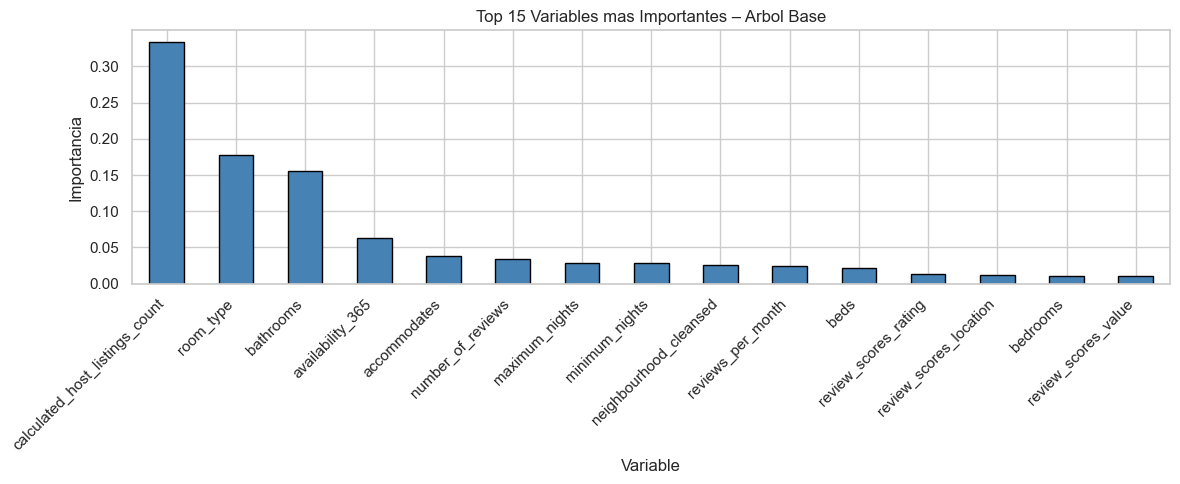

Top 10 variables:
calculated_host_listings_count    0.333057
room_type                         0.177333
bathrooms                         0.155475
availability_365                  0.062938
accommodates                      0.037603
number_of_reviews                 0.033475
maximum_nights                    0.029127
minimum_nights                    0.028205
neighbourhood_cleansed            0.025665
reviews_per_month                 0.023869


In [36]:
# Importancia de variables del árbol base
importancias = pd.Series(arbol_base.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(12, 5))
importancias.head(15).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Variables mas Importantes – Arbol Base')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 variables:')
print(importancias.head(10).to_string())

### Actividad 6 - Predicción y análisis del árbol

In [37]:
y_pred_base_train = arbol_base.predict(X_train)
y_pred_base_test  = arbol_base.predict(X_test)

print('METRICAS EN ENTRENAMIENTO:')
evaluar_regresion('Arbol Base – Train', y_train, y_pred_base_train)

print('METRICAS EN PRUEBA:')
r_base = evaluar_regresion('Arbol Base – Test', y_test, y_pred_base_test)
resultados.append(r_base)

METRICAS EN ENTRENAMIENTO:
── Arbol Base – Train ──
  RMSE :      86.52  (error en unidades de precio)
  MAE  :       1.56  (error absoluto promedio)
  R²   :     0.9890  (varianza explicada)

METRICAS EN PRUEBA:
── Arbol Base – Test ──
  RMSE :     620.23  (error en unidades de precio)
  MAE  :     166.91  (error absoluto promedio)
  R²   :     0.5450  (varianza explicada)



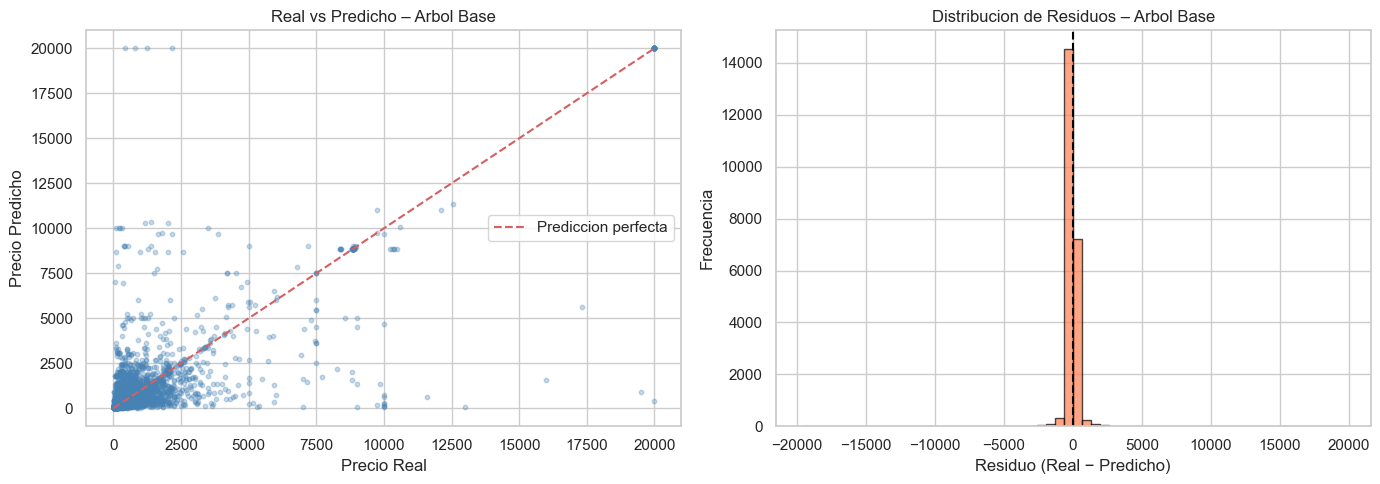

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs predicho
axes[0].scatter(y_test, y_pred_base_test, alpha=0.3, color='steelblue', s=10)
lim = float(max(y_test.max(), y_pred_base_test.max()))
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Prediccion perfecta')
axes[0].set_xlabel('Precio Real')
axes[0].set_ylabel('Precio Predicho')
axes[0].set_title('Real vs Predicho – Arbol Base')
axes[0].legend()

# Residuos
residuos = y_test.values - y_pred_base_test
axes[1].hist(residuos, bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residuo (Real − Predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de Residuos – Arbol Base')

plt.tight_layout()
plt.show()

### Ejercicio 7 – Tuneo de profundidad: selección del mejor árbol de regresión

In [39]:
# Top 10 variables para modelos con selección de variables
top10_vars = importancias.head(10).index.tolist()
print('Top 10 variables:', top10_vars)

Top 10 variables: ['calculated_host_listings_count', 'room_type', 'bathrooms', 'availability_365', 'accommodates', 'number_of_reviews', 'maximum_nights', 'minimum_nights', 'neighbourhood_cleansed', 'reviews_per_month']


In [40]:
# Al menos 3 modelos adicionales variando profundidad y/o selección de variables
configuraciones = [
    ('Arbol prof=3  – Todas',   3,  X_train.columns.tolist()),
    ('Arbol prof=5  – Todas',   5,  X_train.columns.tolist()),
    ('Arbol prof=10 – Todas',   10, X_train.columns.tolist()),
    ('Arbol prof=10 – Top10',   10, top10_vars),
    ('Arbol prof=15 – Top10',   15, top10_vars),
]

modelos_arbol = {}

for nombre, prof, cols in configuraciones:
    m = DecisionTreeRegressor(max_depth=prof, random_state=RANDOM_STATE)
    m.fit(X_train[cols], y_train)
    y_pred = m.predict(X_test[cols])
    metricas = evaluar_regresion(nombre, y_test, y_pred)
    resultados.append(metricas)
    modelos_arbol[nombre] = (m, cols)

── Arbol prof=3  – Todas ──
  RMSE :     801.31  (error en unidades de precio)
  MAE  :     214.23  (error absoluto promedio)
  R²   :     0.2406  (varianza explicada)

── Arbol prof=5  – Todas ──
  RMSE :     691.69  (error en unidades de precio)
  MAE  :     192.91  (error absoluto promedio)
  R²   :     0.4342  (varianza explicada)

── Arbol prof=10 – Todas ──
  RMSE :     549.40  (error en unidades de precio)
  MAE  :     155.57  (error absoluto promedio)
  R²   :     0.6430  (varianza explicada)

── Arbol prof=10 – Top10 ──
  RMSE :     538.34  (error en unidades de precio)
  MAE  :     154.14  (error absoluto promedio)
  R²   :     0.6572  (varianza explicada)

── Arbol prof=15 – Top10 ──
  RMSE :     560.99  (error en unidades de precio)
  MAE  :     151.08  (error absoluto promedio)
  R²   :     0.6278  (varianza explicada)



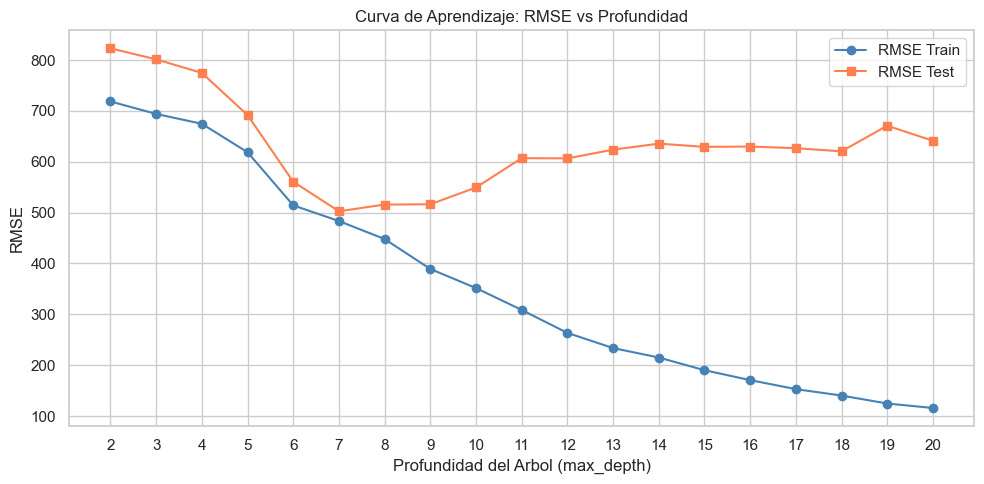

Profundidad optima segun RMSE en test: 7


In [41]:
# Curva de aprendizaje: RMSE en train vs test según profundidad
profundidades    = list(range(2, 21))
rmse_train_lista = []
rmse_test_lista  = []

for d in profundidades:
    m = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    rmse_train_lista.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train))))
    rmse_test_lista.append(np.sqrt(mean_squared_error(y_test,  m.predict(X_test))))

plt.figure(figsize=(10, 5))
plt.plot(profundidades, rmse_train_lista, marker='o', label='RMSE Train', color='steelblue')
plt.plot(profundidades, rmse_test_lista,  marker='s', label='RMSE Test',  color='coral')
plt.xlabel('Profundidad del Arbol (max_depth)')
plt.ylabel('RMSE')
plt.title('Curva de Aprendizaje: RMSE vs Profundidad')
plt.legend()
plt.xticks(profundidades)
plt.tight_layout()
plt.show()

mejor_d = profundidades[np.argmin(rmse_test_lista)]
print(f'Profundidad optima segun RMSE en test: {mejor_d}')

=== MEJOR ARBOL DE REGRESION (max_depth=7) ===
── Mejor Arbol (prof=7) ──
  RMSE :     502.67  (error en unidades de precio)
  MAE  :     165.94  (error absoluto promedio)
  R²   :     0.7012  (varianza explicada)



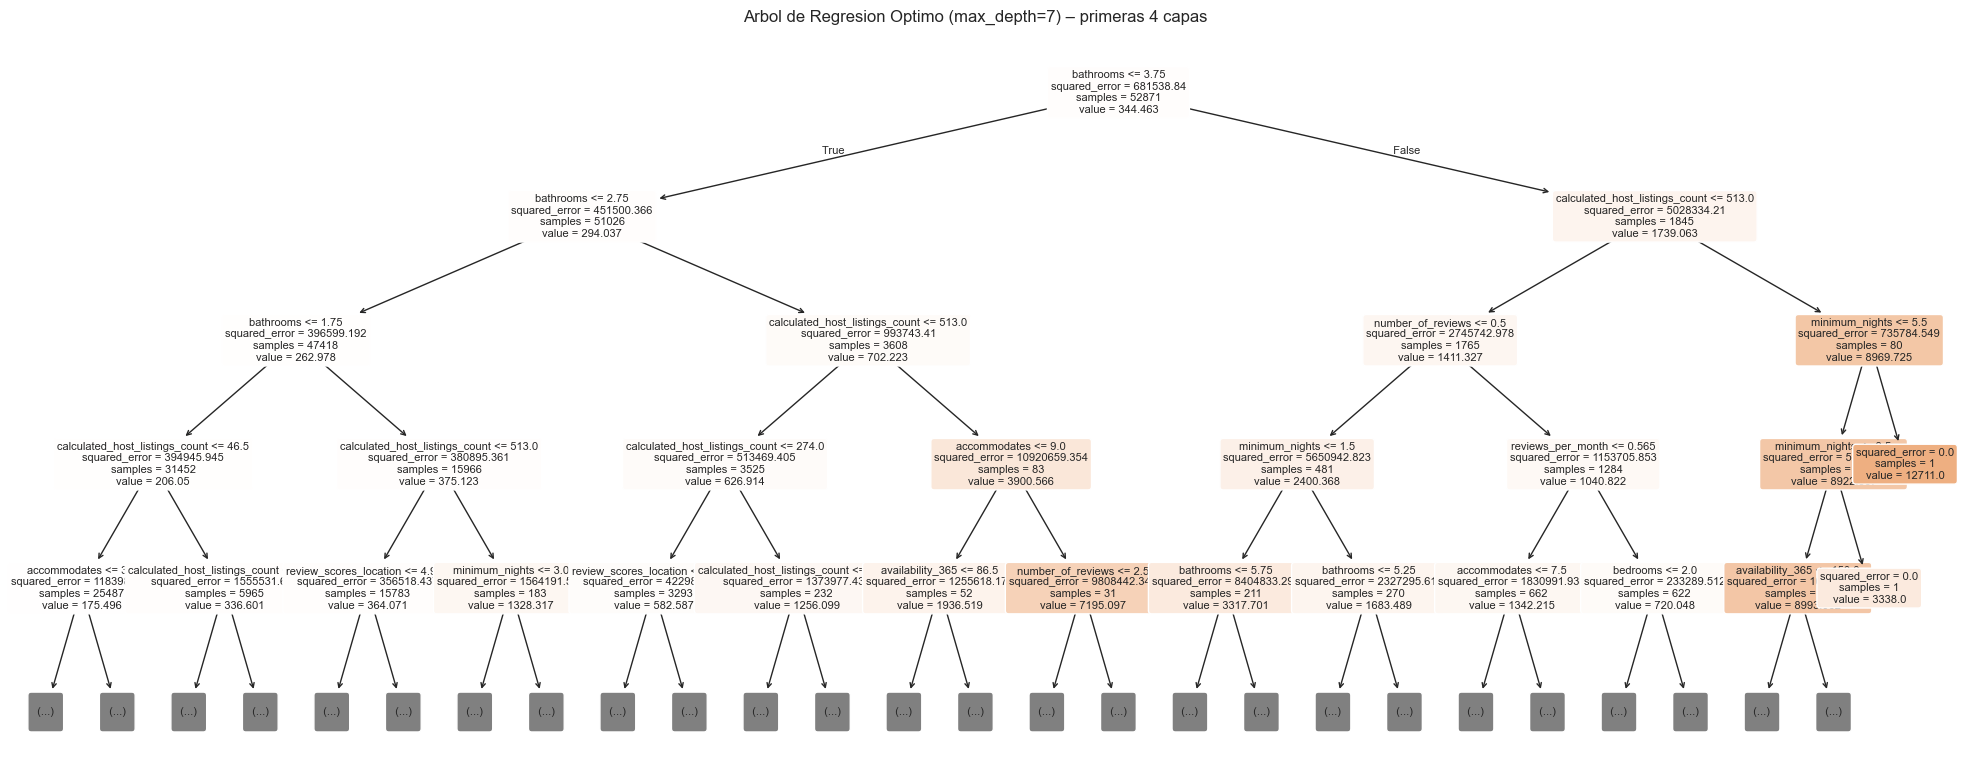

In [42]:
# Mejor árbol de regresión
mejor_arbol_reg = DecisionTreeRegressor(max_depth=mejor_d, random_state=RANDOM_STATE)
mejor_arbol_reg.fit(X_train, y_train)
y_pred_mejor_arbol = mejor_arbol_reg.predict(X_test)

print(f'=== MEJOR ARBOL DE REGRESION (max_depth={mejor_d}) ===')
r_mejor_arbol = evaluar_regresion(f'Mejor Arbol (prof={mejor_d})', y_test, y_pred_mejor_arbol)
resultados.append(r_mejor_arbol)

# Visualizar árbol (hasta profundidad 4 para que sea legible)
plt.figure(figsize=(20, 8))
plot_tree(mejor_arbol_reg, feature_names=X_train.columns.tolist(),
          max_depth=4, filled=True, rounded=True, fontsize=8)
plt.title(f'Arbol de Regresion Optimo (max_depth={mejor_d}) – primeras 4 capas')
plt.tight_layout()
plt.show()

### Ejercicio 8 – Comparación con Regresión Lineal

In [43]:
# Escalar para modelos lineales (necesario por las distintas magnitudes)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

In [44]:
# ── Modelo 1: Regresión Lineal Simple ────────────────────────────────────────
rl = LinearRegression()
rl.fit(X_train_sc, y_train)
resultados.append(evaluar_regresion('Regresion Lineal Simple', y_test, rl.predict(X_test_sc)))

── Regresion Lineal Simple ──
  RMSE :     841.71  (error en unidades de precio)
  MAE  :     260.78  (error absoluto promedio)
  R²   :     0.1621  (varianza explicada)



In [45]:
# ── Modelo 2: Ridge (L2) – controla multicolinealidad entre accommodates/beds/bedrooms ─
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_sc, y_train)
resultados.append(evaluar_regresion('Regresion Ridge (L2, alpha=10)', y_test, ridge.predict(X_test_sc)))

── Regresion Ridge (L2, alpha=10) ──
  RMSE :     841.71  (error en unidades de precio)
  MAE  :     260.76  (error absoluto promedio)
  R²   :     0.1621  (varianza explicada)



In [46]:
# ── Modelo 3: Lasso (L1) – selección automática de variables ─────────────────
lasso = Lasso(alpha=1.0, max_iter=5000)
lasso.fit(X_train_sc, y_train)
resultados.append(evaluar_regresion('Regresion Lasso (L1, alpha=1)', y_test, lasso.predict(X_test_sc)))

eliminadas = pd.Series(lasso.coef_, index=X_train.columns)
print('Variables llevadas a 0 por Lasso:', eliminadas[eliminadas == 0].index.tolist() or 'ninguna')

── Regresion Lasso (L1, alpha=1) ──
  RMSE :     841.80  (error en unidades de precio)
  MAE  :     259.20  (error absoluto promedio)
  R²   :     0.1619  (varianza explicada)

Variables llevadas a 0 por Lasso: ninguna


In [47]:
# ── Modelo 4: Regresión Lineal con Log(price) – mejora normalidad ─────────────
rl_log = LinearRegression()
rl_log.fit(X_train_sc, np.log1p(y_train))
y_pred_log = np.expm1(rl_log.predict(X_test_sc))
resultados.append(evaluar_regresion('Regresion Lineal Log(price)', y_test, y_pred_log))

── Regresion Lineal Log(price) ──
  RMSE :     827.40  (error en unidades de precio)
  MAE  :     185.75  (error absoluto promedio)
  R²   :     0.1903  (varianza explicada)



In [48]:
# ── Tabla comparativa final ───────────────────────────────────────────────────
df_comp = pd.DataFrame(resultados).drop_duplicates('modelo').sort_values('RMSE').reset_index(drop=True)

print('══════════════════════════════════════════════════════════')
print('       COMPARACION FINAL DE MODELOS DE REGRESION')
print('══════════════════════════════════════════════════════════')
print(df_comp[['modelo','RMSE','MAE','R2']].to_string(index=False))
print(f'\nMejor modelo: {df_comp.iloc[0]["modelo"]}')

══════════════════════════════════════════════════════════
       COMPARACION FINAL DE MODELOS DE REGRESION
══════════════════════════════════════════════════════════
                        modelo       RMSE        MAE       R2
          Mejor Arbol (prof=7) 502.673118 165.943593 0.701155
         Arbol prof=10 – Top10 538.338528 154.135155 0.657244
         Arbol prof=10 – Todas 549.395288 155.569070 0.643020
         Arbol prof=15 – Top10 560.985590 151.081675 0.627799
             Arbol Base – Test 620.225991 166.910949 0.545039
         Arbol prof=5  – Todas 691.685320 192.907821 0.434163
         Arbol prof=3  – Todas 801.309919 214.230844 0.240591
   Regresion Lineal Log(price) 827.396675 185.748917 0.190341
       Regresion Lineal Simple 841.709585 260.783511 0.162087
Regresion Ridge (L2, alpha=10) 841.711526 260.759257 0.162083
 Regresion Lasso (L1, alpha=1) 841.803479 259.199003 0.161900

Mejor modelo: Mejor Arbol (prof=7)


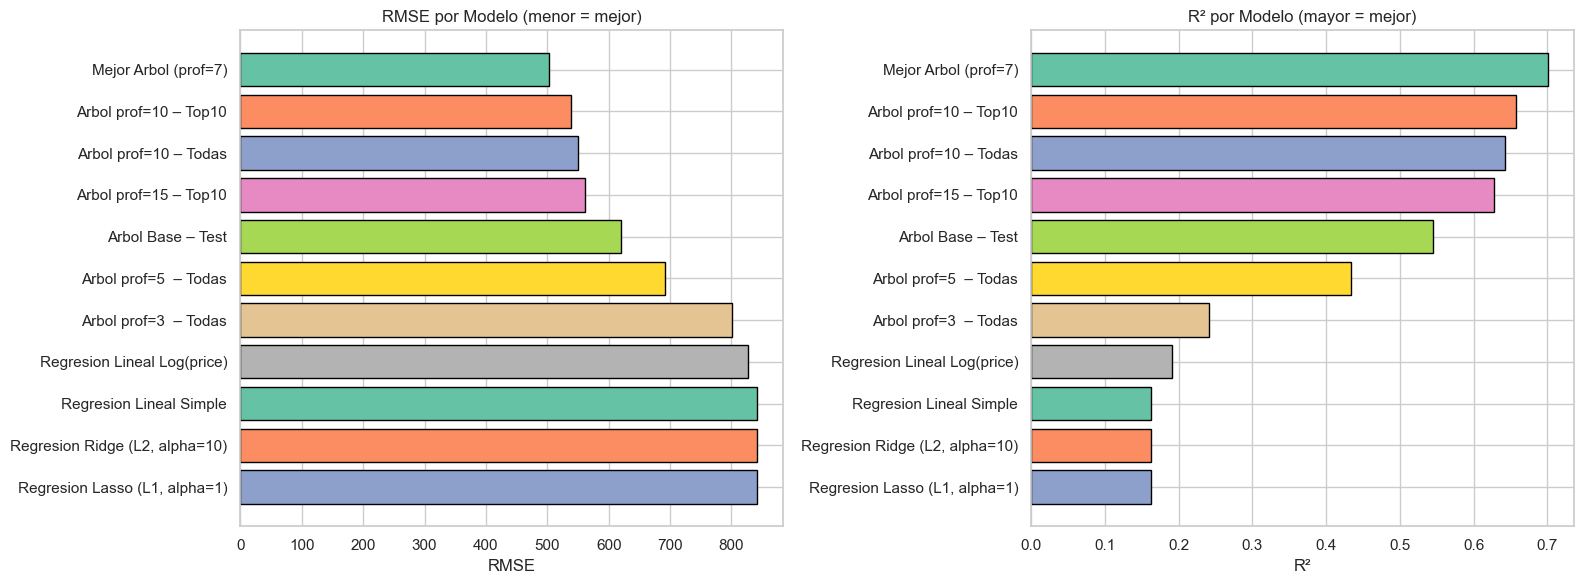

In [49]:
# Gráfica comparativa
palette = sns.color_palette('Set2', len(df_comp))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(df_comp['modelo'], df_comp['RMSE'], color=palette, edgecolor='black')
axes[0].set_title('RMSE por Modelo (menor = mejor)')
axes[0].set_xlabel('RMSE')
axes[0].invert_yaxis()

axes[1].barh(df_comp['modelo'], df_comp['R2'], color=palette, edgecolor='black')
axes[1].set_title('R² por Modelo (mayor = mejor)')
axes[1].set_xlabel('R²')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Ejercicio 9 – Creación de la variable categórica de precio

Se crea `precio_categoria` con tres clases: **Económica**, **Intermedia** y **Cara**,
usando los percentiles 25 y 75 como cortes.

In [50]:
precio = df_procesado['price']

p25 = precio.quantile(0.25)
p75 = precio.quantile(0.75)

print('Distribucion del precio:')
print(precio.describe().round(2).to_string())
print(f'\nPercentil 25 (P25): ${p25:.2f}')
print(f'Percentil 75 (P75): ${p75:.2f}')

Distribucion del precio:
count    75531.00
mean       347.94
std        854.85
min          8.00
25%        119.00
50%        191.00
75%        320.00
max      20000.00

Percentil 25 (P25): $119.00
Percentil 75 (P75): $320.00


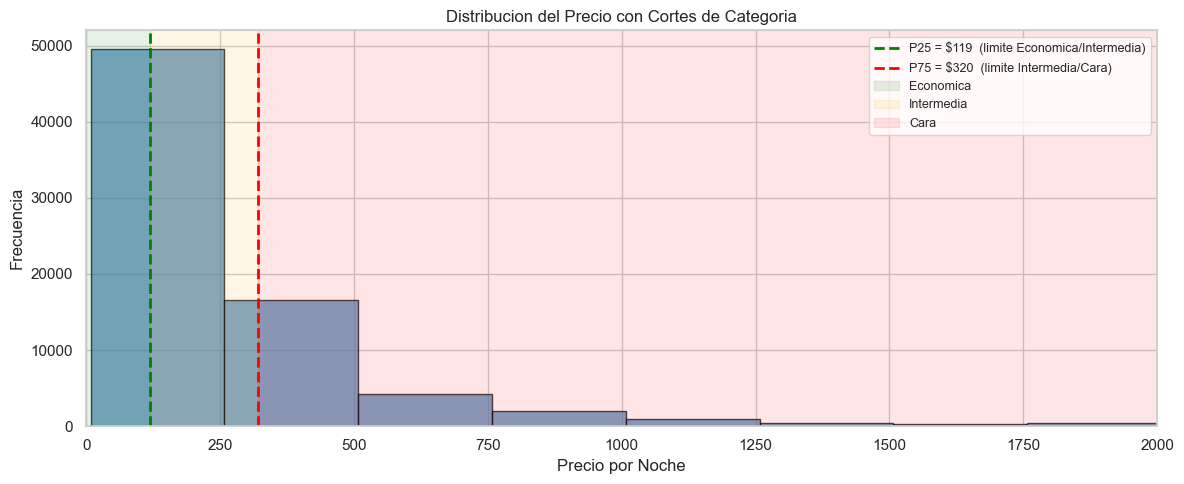

In [51]:
# Visualización con los cortes marcados
plt.figure(figsize=(12, 5))
plt.hist(precio, bins=80, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(p25, color='green', linestyle='--', lw=2, label=f'P25 = ${p25:.0f}  (limite Economica/Intermedia)')
plt.axvline(p75, color='red',   linestyle='--', lw=2, label=f'P75 = ${p75:.0f}  (limite Intermedia/Cara)')
plt.axvspan(0,    p25,          alpha=0.1, color='green',  label='Economica')
plt.axvspan(p25,  p75,          alpha=0.1, color='orange', label='Intermedia')
plt.axvspan(p75,  precio.max(), alpha=0.1, color='red',    label='Cara')
plt.title('Distribucion del Precio con Cortes de Categoria')
plt.xlabel('Precio por Noche')
plt.ylabel('Frecuencia')
plt.legend(fontsize=9)
plt.xlim(0, 2000)
plt.tight_layout()
plt.show()

In [52]:
def categorizar(p):
    if p < p25:   return 'Economica'
    elif p < p75: return 'Intermedia'
    else:         return 'Cara'

df_procesado['precio_categoria'] = df_procesado['price'].apply(categorizar)

conteo = df_procesado['precio_categoria'].value_counts()
pct    = df_procesado['precio_categoria'].value_counts(normalize=True).mul(100).round(1)

print('=== DISTRIBUCION DE precio_categoria ===')
print(pd.DataFrame({'conteo': conteo, 'pct (%)': pct}).to_string())

=== DISTRIBUCION DE precio_categoria ===
                  conteo  pct (%)
precio_categoria                 
Intermedia         37989     50.3
Cara               18960     25.1
Economica          18582     24.6


In [53]:
# Estadísticas de precio por categoría
print('=== ESTADISTICAS DE PRECIO POR CATEGORIA ===')
print(df_procesado.groupby('precio_categoria')['price'].describe().round(2).to_string())

=== ESTADISTICAS DE PRECIO POR CATEGORIA ===
                    count    mean      std    min    25%    50%     75%      max
precio_categoria                                                                
Cara              18960.0  906.03  1574.73  320.0  390.0  507.0  804.25  20000.0
Economica         18582.0   82.44    24.77    8.0   65.0   87.0  103.00    118.0
Intermedia        37989.0  199.28    55.05  119.0  152.0  190.0  241.00    319.0


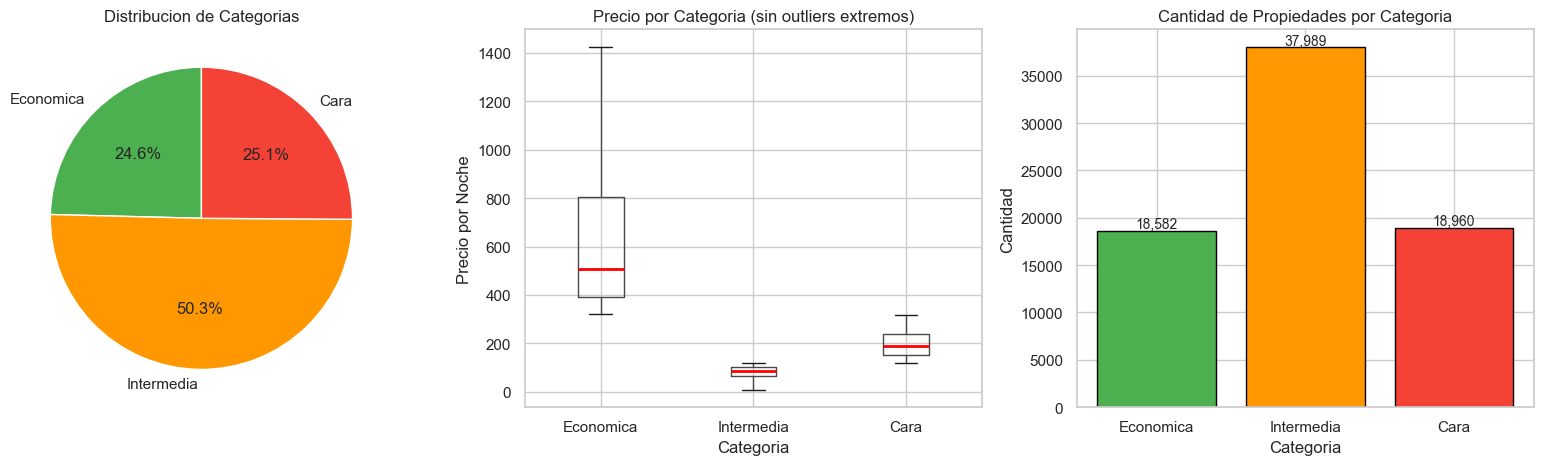

In [54]:
orden          = ['Economica', 'Intermedia', 'Cara']
colores_cat    = {'Economica': '#4caf50', 'Intermedia': '#ff9800', 'Cara': '#f44336'}
conteo_ord     = conteo.reindex(orden)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Pie
axes[0].pie(conteo_ord, labels=orden, autopct='%1.1f%%',
            colors=[colores_cat[c] for c in orden], startangle=90)
axes[0].set_title('Distribucion de Categorias')

# 2. Boxplot precio por categoría
df_procesado.boxplot(column='price', by='precio_categoria', ax=axes[1],
                     showfliers=False,
                     medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Precio por Categoria (sin outliers extremos)')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Precio por Noche')
plt.sca(axes[1])
plt.xticks([1, 2, 3], orden)

# 3. Barras de conteo
bars = axes[2].bar(orden, [conteo_ord[c] for c in orden],
                   color=[colores_cat[c] for c in orden], edgecolor='black')
axes[2].set_title('Cantidad de Propiedades por Categoria')
axes[2].set_xlabel('Categoria')
axes[2].set_ylabel('Cantidad')
for bar, cat in zip(bars, orden):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 300,
                 f'{conteo_ord[cat]:,}', ha='center', fontsize=10)

plt.suptitle('')
plt.tight_layout()
plt.show()

C:\Users\jlope\AppData\Local\Temp\ipykernel_35536\2783143033.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_plot, labels=orden, patch_artist=True, showfliers=False)
C:\Users\jlope\AppData\Local\Temp\ipykernel_35536\2783143033.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_plot, labels=orden, patch_artist=True, showfliers=False)
C:\Users\jlope\AppData\Local\Temp\ipykernel_35536\2783143033.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_plot, labels=orden, patch_artist=True, showfliers=False)


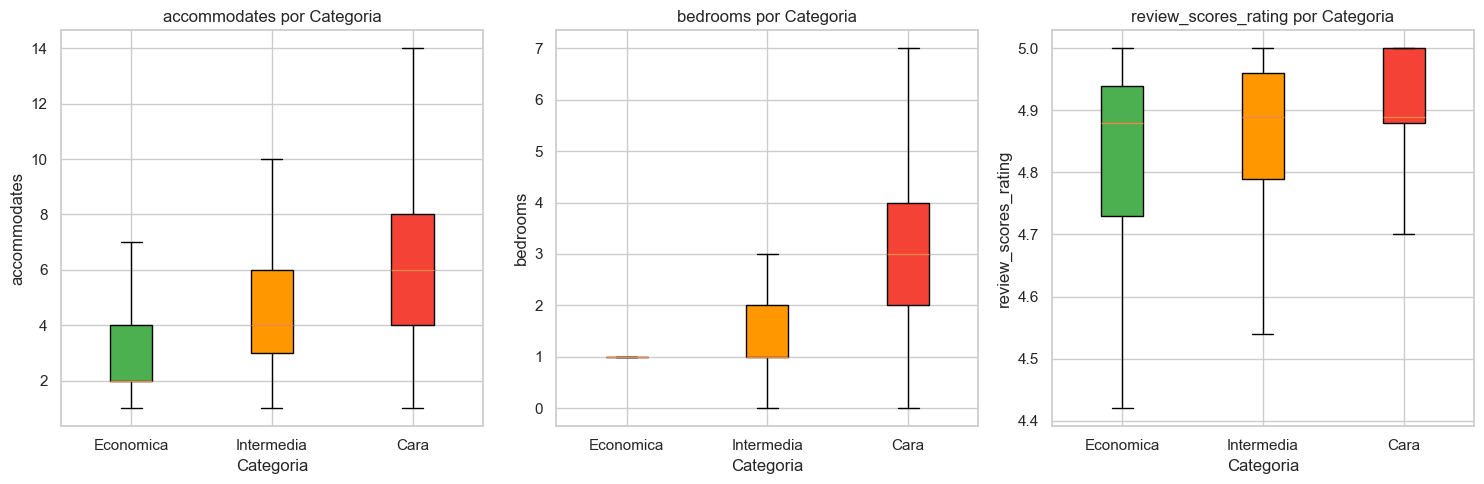

In [55]:
# Relación entre categoría y variables clave (confirma coherencia de los cortes)
vars_check = ['accommodates', 'bedrooms', 'review_scores_rating']
vars_check  = [v for v in vars_check if v in df_procesado.columns]

fig, axes = plt.subplots(1, len(vars_check), figsize=(15, 5))
for i, var in enumerate(vars_check):
    data_plot = [df_procesado[df_procesado['precio_categoria'] == c][var].dropna() for c in orden]
    bp = axes[i].boxplot(data_plot, labels=orden, patch_artist=True, showfliers=False)
    for patch, cat in zip(bp['boxes'], orden):
        patch.set_facecolor(colores_cat[cat])
    axes[i].set_title(f'{var} por Categoria')
    axes[i].set_xlabel('Categoria')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

In [56]:
# Guardar dataset con la nueva variable para los ejercicios 10–15
df_procesado.to_csv('data/df_con_categoria.csv', index=False)

print('Variable precio_categoria creada correctamente.')
print(f'  Economica  : precio < ${p25:.0f}/noche')
print(f'  Intermedia : ${p25:.0f} <= precio < ${p75:.0f}/noche')
print(f'  Cara       : precio >= ${p75:.0f}/noche')
print(f'Archivo guardado: data/df_con_categoria.csv')

Variable precio_categoria creada correctamente.
  Economica  : precio < $119/noche
  Intermedia : $119 <= precio < $320/noche
  Cara       : precio >= $320/noche
Archivo guardado: data/df_con_categoria.csv


In [57]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


### Ejercicio 10 – Árbol de Clasificación

Se construye un árbol de clasificación para predecir la categoría de precio (precio_categoria).  
**Importante:** la variable price (precio numérico) se excluye de las features para evitar fuga de datos,
ya que precio_categoria fue derivada directamente de ella.

In [58]:
EXCLUIR = ['price', 'precio_categoria']
feature_cols = [c for c in df_procesado.columns if c not in EXCLUIR]

X_clf = df_procesado[feature_cols]
y_clf = df_procesado['precio_categoria']

print('Variables utilizadas como predictores:', feature_cols)
print(f'\nDimensiones: X={X_clf.shape}, y={y_clf.shape}')
print('\nDistribución de clases:')
print(y_clf.value_counts())
print('\nProporción de clases:')
print(y_clf.value_counts(normalize=True).round(3))

Variables utilizadas como predictores: ['room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'host_is_superhost', 'neighbourhood_cleansed', 'instant_bookable']

Dimensiones: X=(75531, 20), y=(75531,)

Distribución de clases:
precio_categoria
Intermedia    37989
Cara          18960
Economica     18582
Name: count, dtype: int64

Proporción de clases:
precio_categoria
Intermedia    0.503
Cara          0.251
Economica     0.246
Name: proportion, dtype: float64


In [59]:
from sklearn.model_selection import train_test_split

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf        # garantiza misma proporción en train y test
)

print(f'Entrenamiento : {X_train_c.shape[0]} filas')
print(f'Prueba        : {X_test_c.shape[0]} filas')
print('\nClases en train:')
print(y_train_c.value_counts())
print('\nClases en test:')
print(y_test_c.value_counts())

Entrenamiento : 60424 filas
Prueba        : 15107 filas

Clases en train:
precio_categoria
Intermedia    30391
Cara          15168
Economica     14865
Name: count, dtype: int64

Clases en test:
precio_categoria
Intermedia    7598
Cara          3792
Economica     3717
Name: count, dtype: int64


In [60]:
clf_base = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)
clf_base.fit(X_train_c, y_train_c)

y_pred_base = clf_base.predict(X_test_c)
acc_base = accuracy_score(y_test_c, y_pred_base)

print(' Árbol de Clasificación BASE (sin poda) ')
print(f'Profundidad real del árbol : {clf_base.get_depth()}')
print(f'Accuracy en test           : {acc_base:.4f} ({acc_base*100:.2f}%)')
print()
print(classification_report(y_test_c, y_pred_base))

 Árbol de Clasificación BASE (sin poda) 
Profundidad real del árbol : 37
Accuracy en test           : 0.6828 (68.28%)

              precision    recall  f1-score   support

        Cara       0.67      0.68      0.67      3792
   Economica       0.66      0.65      0.66      3717
  Intermedia       0.70      0.70      0.70      7598

    accuracy                           0.68     15107
   macro avg       0.68      0.68      0.68     15107
weighted avg       0.68      0.68      0.68     15107



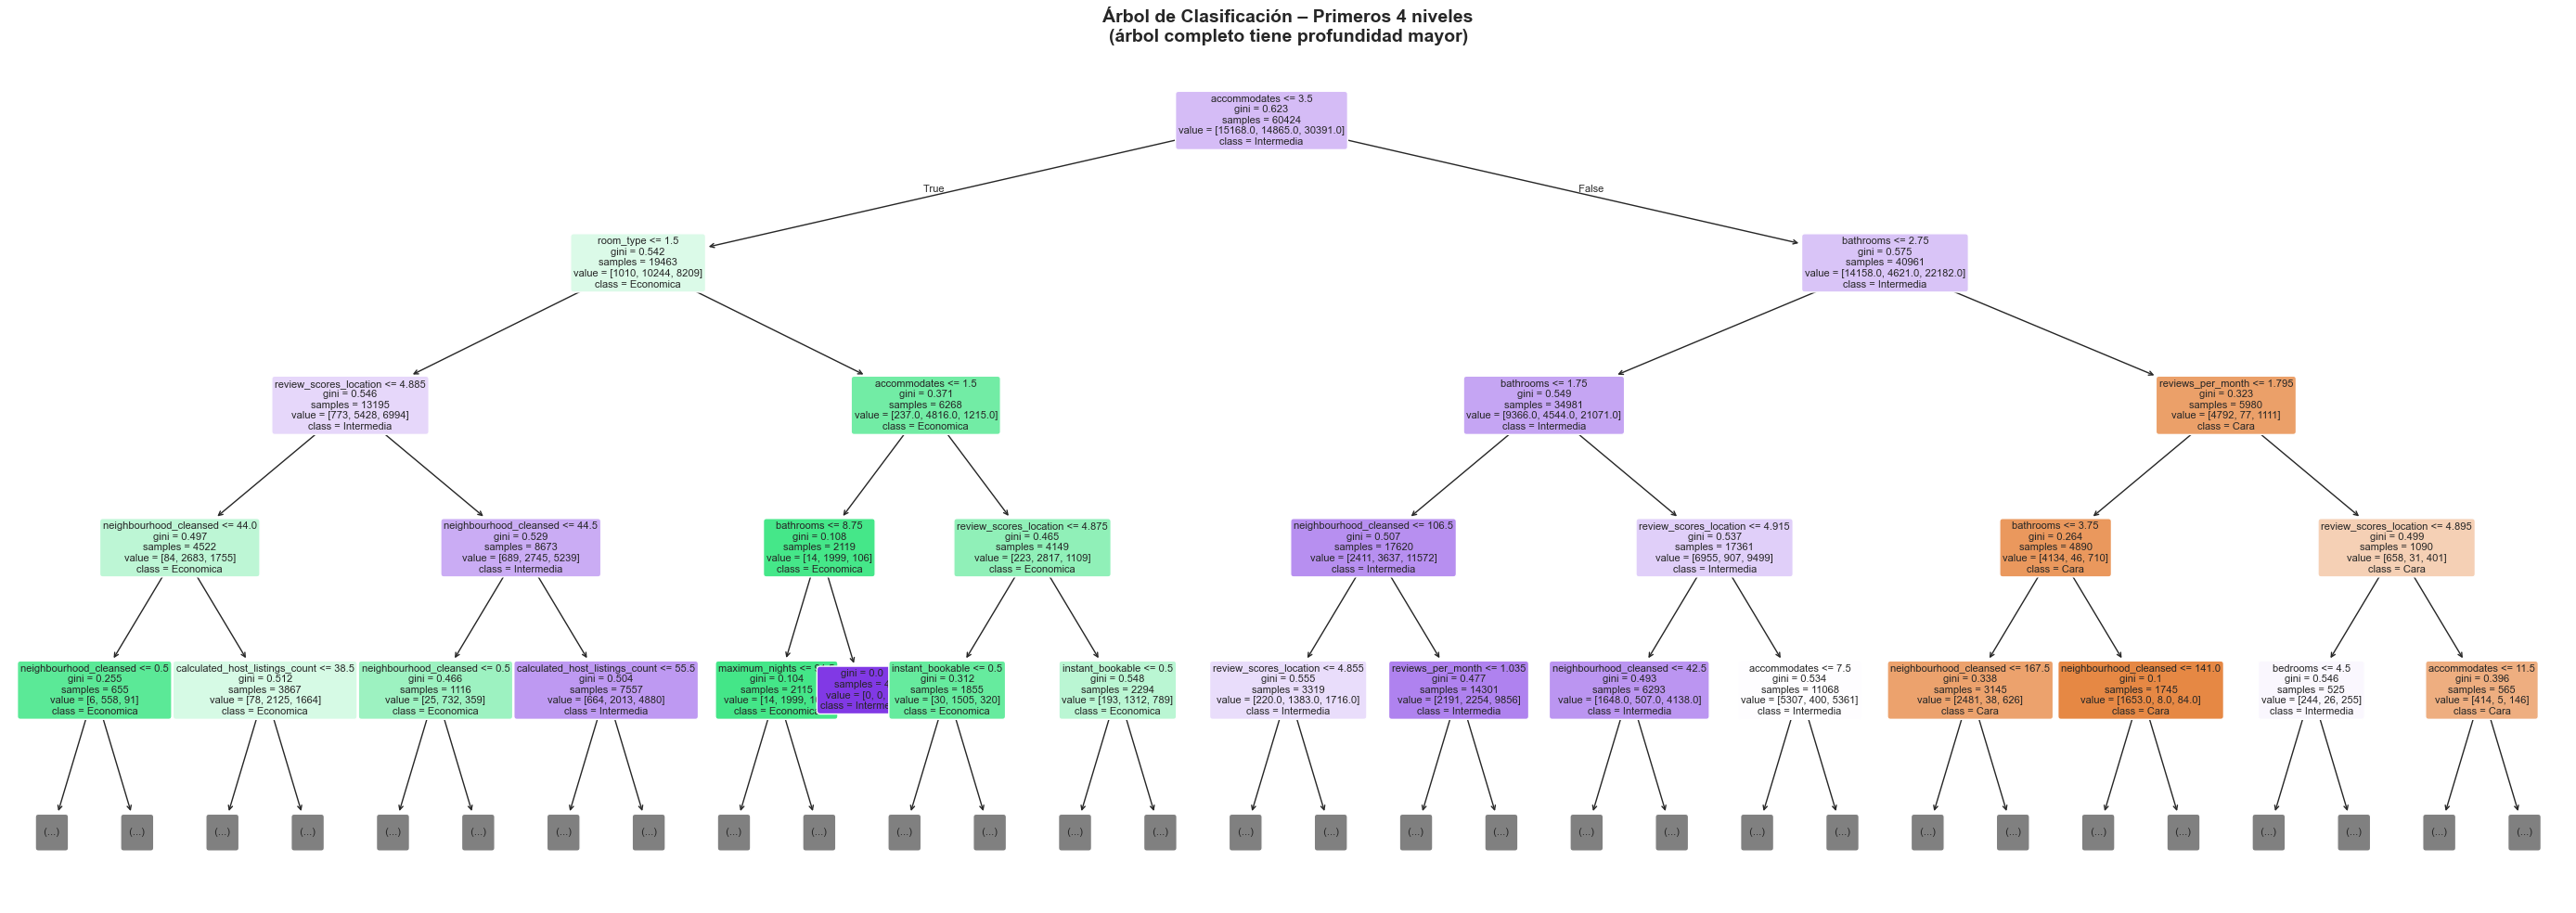

Figura guardada como arbol_clasificacion_base.png


In [61]:
orden_clases = ['Economica', 'Intermedia', 'Cara']
colores_nodos = ['#2ecc71', '#f39c12', '#e74c3c']   # verde, naranja, rojo

fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    clf_base,
    feature_names=feature_cols,
    class_names=clf_base.classes_,
    filled=True,
    rounded=True,
    max_depth=4,          # mostramos solo los primeros 4 niveles
    fontsize=8,
    ax=ax
)
ax.set_title(
    'Árbol de Clasificación – Primeros 4 niveles\n(árbol completo tiene profundidad mayor)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('arbol_clasificacion_base.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada como arbol_clasificacion_base.png')

### Ejercicio 11 – Eficiencia del modelo sobre el conjunto de prueba

In [62]:

print('Evaluación sobre el conjunto de PRUEBA ')
print(f'Total de muestras en test : {len(y_test_c)}')
print(f'Accuracy global           : {acc_base:.4f} ({acc_base*100:.2f}%)')
print()
print('Reporte por clase:')
print(classification_report(y_test_c, y_pred_base,
                             target_names=clf_base.classes_))

# Tabla comparativa real vs predicho
df_eval = pd.DataFrame({'Real': y_test_c.values, 'Predicho': y_pred_base})
tabla_comp = pd.crosstab(df_eval['Real'], df_eval['Predicho'],
                          margins=True, margins_name='Total')
print('\nTabla de contingencia (filas=Real, columnas=Predicho):')
print(tabla_comp)

Evaluación sobre el conjunto de PRUEBA 
Total de muestras en test : 15107
Accuracy global           : 0.6828 (68.28%)

Reporte por clase:
              precision    recall  f1-score   support

        Cara       0.67      0.68      0.67      3792
   Economica       0.66      0.65      0.66      3717
  Intermedia       0.70      0.70      0.70      7598

    accuracy                           0.68     15107
   macro avg       0.68      0.68      0.68     15107
weighted avg       0.68      0.68      0.68     15107


Tabla de contingencia (filas=Real, columnas=Predicho):
Predicho    Cara  Economica  Intermedia  Total
Real                                          
Cara        2561        109        1122   3792
Economica    127       2405        1185   3717
Intermedia  1144       1105        5349   7598
Total       3832       3619        7656  15107


### Ejercicio 12 – Matriz de Confusión y Análisis de Errores

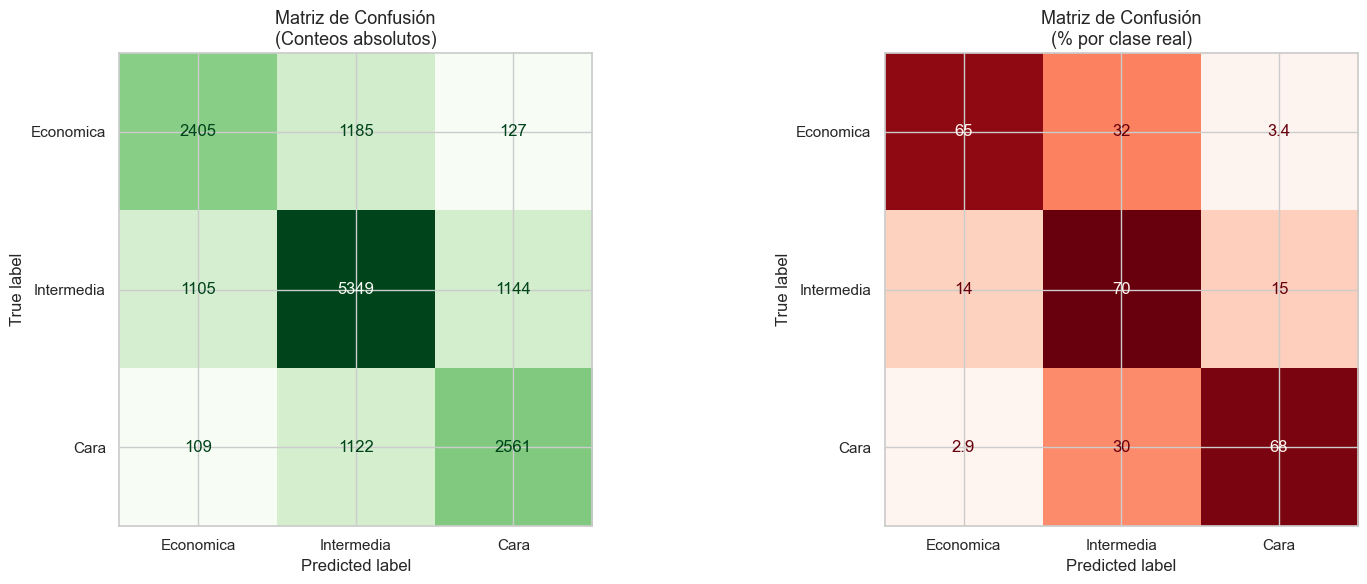


=== Análisis de errores por clase ===
Economica   : 2405/3717 correctos  (64.7% recall)  |  1312 errores
Intermedia  : 5349/7598 correctos  (70.4% recall)  |  2249 errores
Cara        : 2561/3792 correctos  (67.5% recall)  |  1231 errores


In [63]:
orden = ['Economica', 'Intermedia', 'Cara']
# filtramos solo las clases presentes
orden_presente = [c for c in orden if c in clf_base.classes_]

cm = confusion_matrix(y_test_c, y_pred_base, labels=orden_presente)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Izquierda: conteos absolutos
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=orden_presente)
disp1.plot(ax=axes[0], cmap='Greens', colorbar=False)
axes[0].set_title('Matriz de Confusión\n(Conteos absolutos)', fontsize=13)

# Derecha: porcentajes por fila (tasa de error/acierto por clase real)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_pct.round(1), display_labels=orden_presente)
disp2.plot(ax=axes[1], cmap='Reds', colorbar=False)
axes[1].set_title('Matriz de Confusión\n(% por clase real)', fontsize=13)

plt.tight_layout()
plt.savefig('matriz_confusion_base.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Resumen cuantitativo de errores ────────────────────────────────────────
print('\n=== Análisis de errores por clase ===')
for i, clase in enumerate(orden_presente):
    total_real = cm[i].sum()
    correctos  = cm[i, i]
    errores    = total_real - correctos
    print(f'{clase:12s}: {correctos}/{total_real} correctos  '
          f'({correctos/total_real*100:.1f}% recall)  |  '
          f'{errores} errores')

### Ejercicio 13 – Validación Cruzada

In [64]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

clf_cv = DecisionTreeClassifier(criterion='gini', random_state=42)

cv_scores = cross_val_score(
    clf_cv, X_clf, y_clf,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

print('=== Validación Cruzada Estratificada (5-fold) ===')
print(f'Accuracy por fold : {np.round(cv_scores, 4)}')
print(f'Media             : {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'Desv. estándar    : {cv_scores.std():.4f}')
print(f'IC 95%            : [{cv_scores.mean()-2*cv_scores.std():.4f},'
      f' {cv_scores.mean()+2*cv_scores.std():.4f}]')

# Comparación con el modelo base
print('\n=== Comparación con modelo base ===')
print(f'Modelo base (train/test split)   : {acc_base:.4f}')
print(f'Modelo con validación cruzada    : {cv_scores.mean():.4f}')
mejora = cv_scores.mean() - acc_base
print(f'Diferencia                       : {mejora:+.4f}')

=== Validación Cruzada Estratificada (5-fold) ===
Accuracy por fold : [0.679  0.6748 0.6769 0.6762 0.6772]
Media             : 0.6768 (67.68%)
Desv. estándar    : 0.0014
IC 95%            : [0.6741, 0.6796]

=== Comparación con modelo base ===
Modelo base (train/test split)   : 0.6828
Modelo con validación cruzada    : 0.6768
Diferencia                       : -0.0060


In [65]:
clf_cv.fit(X_train_c, y_train_c)
y_pred_cv = clf_cv.predict(X_test_c)
acc_cv_test = accuracy_score(y_test_c, y_pred_cv)

print(f'Accuracy en test (modelo CV, entrenado en train): {acc_cv_test:.4f}')
print()
print(classification_report(y_test_c, y_pred_cv))

Accuracy en test (modelo CV, entrenado en train): 0.6828

              precision    recall  f1-score   support

        Cara       0.67      0.68      0.67      3792
   Economica       0.66      0.65      0.66      3717
  Intermedia       0.70      0.70      0.70      7598

    accuracy                           0.68     15107
   macro avg       0.68      0.68      0.68     15107
weighted avg       0.68      0.68      0.68     15107



### Ejercicio 14 – Tuneo de la Profundidad del Árbol de Clasificación

In [66]:
profundidades = [3, 5, 7, 10, 15, 20, None]   # None = sin restricción
resultados_prof = []

for prof in profundidades:
    clf_p = DecisionTreeClassifier(
        criterion='gini',
        max_depth=prof,
        random_state=42
    )
    # accuracy en train y test
    clf_p.fit(X_train_c, y_train_c)
    acc_train = accuracy_score(y_train_c, clf_p.predict(X_train_c))
    acc_test  = accuracy_score(y_test_c,  clf_p.predict(X_test_c))

    # accuracy con CV (más confiable)
    cv_acc = cross_val_score(clf_p, X_clf, y_clf,
                             cv=StratifiedKFold(5, shuffle=True, random_state=42),
                             scoring='accuracy', n_jobs=-1).mean()

    etiqueta = str(prof) if prof is not None else 'Sin límite'
    resultados_prof.append({
        'profundidad'  : etiqueta,
        'acc_train'    : round(acc_train, 4),
        'acc_test'     : round(acc_test,  4),
        'acc_cv_5fold' : round(cv_acc,    4)
    })

df_prof = pd.DataFrame(resultados_prof)
print('=== Comparación de modelos por profundidad ===')
print(df_prof.to_string(index=False))

=== Comparación de modelos por profundidad ===
profundidad  acc_train  acc_test  acc_cv_5fold
          3     0.6388    0.6398        0.6384
          5     0.6698    0.6672        0.6672
          7     0.6917    0.6798        0.6790
         10     0.7374    0.7048        0.7046
         15     0.8562    0.7126        0.7054
         20     0.9591    0.6941        0.6895
 Sin límite     0.9992    0.6828        0.6768


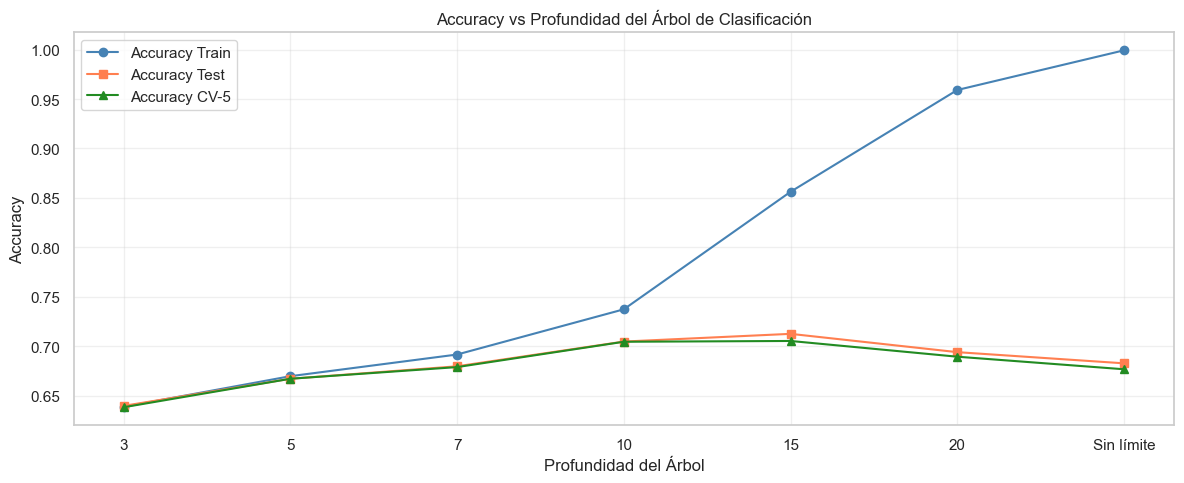


Mejor profundidad (según CV-5): 15
  Accuracy CV-5  : 0.7054
  Accuracy test  : 0.7126


In [67]:
ig, ax = plt.subplots(figsize=(12, 5))

eje_x = range(len(df_prof))
ax.plot(eje_x, df_prof['acc_train'],  marker='o', label='Accuracy Train',  color='steelblue')
ax.plot(eje_x, df_prof['acc_test'],   marker='s', label='Accuracy Test',   color='coral')
ax.plot(eje_x, df_prof['acc_cv_5fold'], marker='^', label='Accuracy CV-5',  color='forestgreen')
ax.set_xticks(eje_x)
ax.set_xticklabels(df_prof['profundidad'])
ax.set_xlabel('Profundidad del Árbol')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Profundidad del Árbol de Clasificación')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('curva_profundidad_clasificacion.png', dpi=120, bbox_inches='tight')
plt.show()

# Selección del mejor modelo
mejor_fila = df_prof.loc[df_prof['acc_cv_5fold'].idxmax()]
print(f"\nMejor profundidad (según CV-5): {mejor_fila['profundidad']}")
print(f"  Accuracy CV-5  : {mejor_fila['acc_cv_5fold']}")
print(f"  Accuracy test  : {mejor_fila['acc_test']}")

=== Mejor Árbol de Clasificación (max_depth=15) ===
Accuracy test : 0.7126 (71.26%)

              precision    recall  f1-score   support

        Cara       0.73      0.65      0.69      3792
   Economica       0.71      0.66      0.68      3717
  Intermedia       0.71      0.77      0.74      7598

    accuracy                           0.71     15107
   macro avg       0.72      0.69      0.70     15107
weighted avg       0.71      0.71      0.71     15107



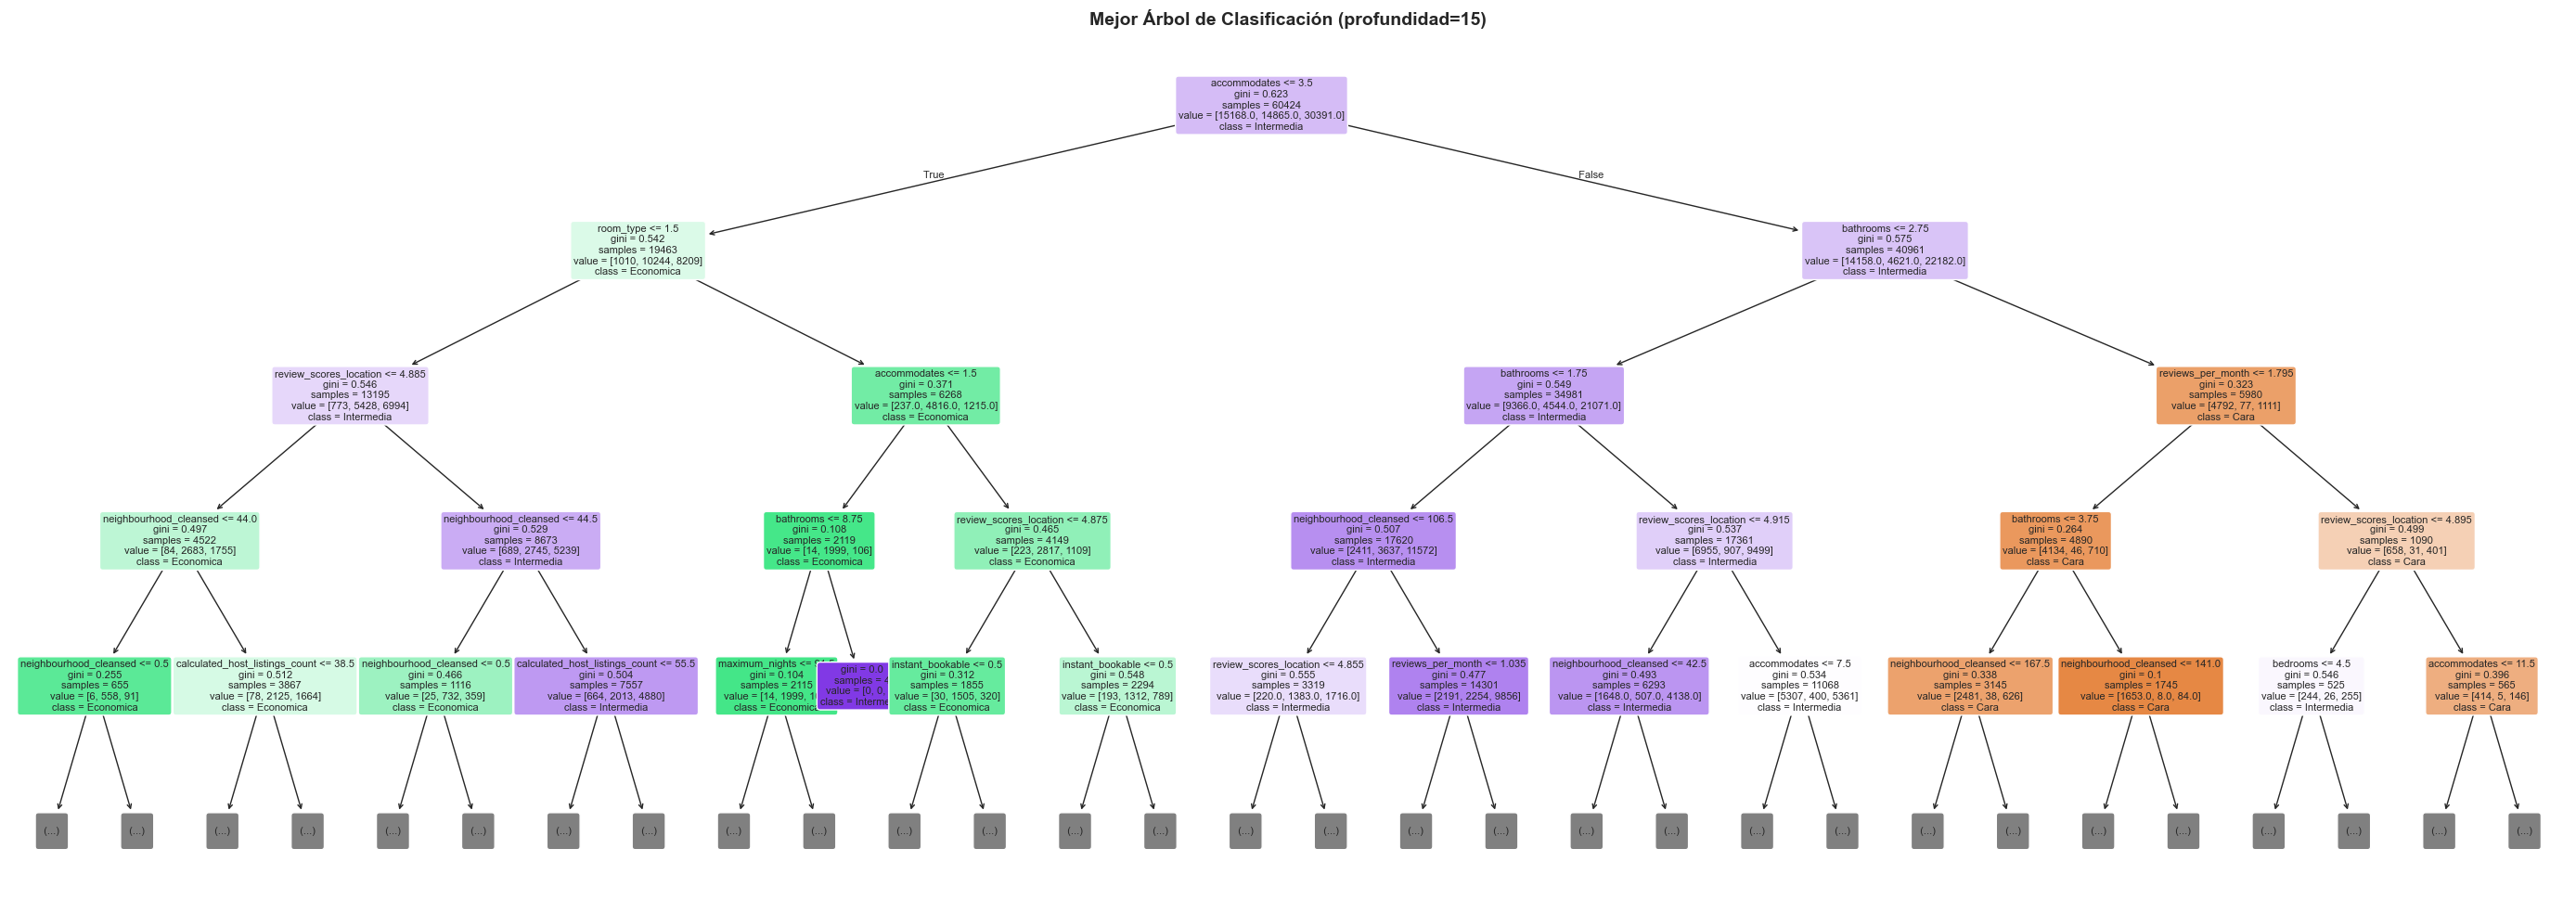

In [68]:
mejor_profundidad_str = mejor_fila['profundidad']
mejor_profundidad = None if mejor_profundidad_str == 'Sin límite' else int(mejor_profundidad_str)

clf_mejor = DecisionTreeClassifier(
    criterion='gini',
    max_depth=mejor_profundidad,
    random_state=42
)
clf_mejor.fit(X_train_c, y_train_c)
y_pred_mejor = clf_mejor.predict(X_test_c)
acc_mejor = accuracy_score(y_test_c, y_pred_mejor)

print(f'=== Mejor Árbol de Clasificación (max_depth={mejor_profundidad}) ===')
print(f'Accuracy test : {acc_mejor:.4f} ({acc_mejor*100:.2f}%)')
print()
print(classification_report(y_test_c, y_pred_mejor))

# Visualización del mejor árbol
fig, ax = plt.subplots(figsize=(28, 10))
plot_tree(
    clf_mejor,
    feature_names=feature_cols,
    class_names=clf_mejor.classes_,
    filled=True,
    rounded=True,
    max_depth=min(4, clf_mejor.get_depth()),
    fontsize=8,
    ax=ax
)
ax.set_title(f'Mejor Árbol de Clasificación (profundidad={mejor_profundidad})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('arbol_clasificacion_mejor.png', dpi=120, bbox_inches='tight')
plt.show()

### Ejercicio 15 – Random Forest: Entrenamiento, Evaluación y Comparación

In [69]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train_c, y_train_c)

y_pred_rf = rf_base.predict(X_test_c)
acc_rf = accuracy_score(y_test_c, y_pred_rf)

print('=== Random Forest – 100 árboles, parámetros por defecto ===')
print(f'Accuracy en test : {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print()
print(classification_report(y_test_c, y_pred_rf))

=== Random Forest – 100 árboles, parámetros por defecto ===
Accuracy en test : 0.7618 (76.18%)

              precision    recall  f1-score   support

        Cara       0.81      0.69      0.74      3792
   Economica       0.79      0.69      0.73      3717
  Intermedia       0.74      0.84      0.78      7598

    accuracy                           0.76     15107
   macro avg       0.78      0.74      0.75     15107
weighted avg       0.77      0.76      0.76     15107



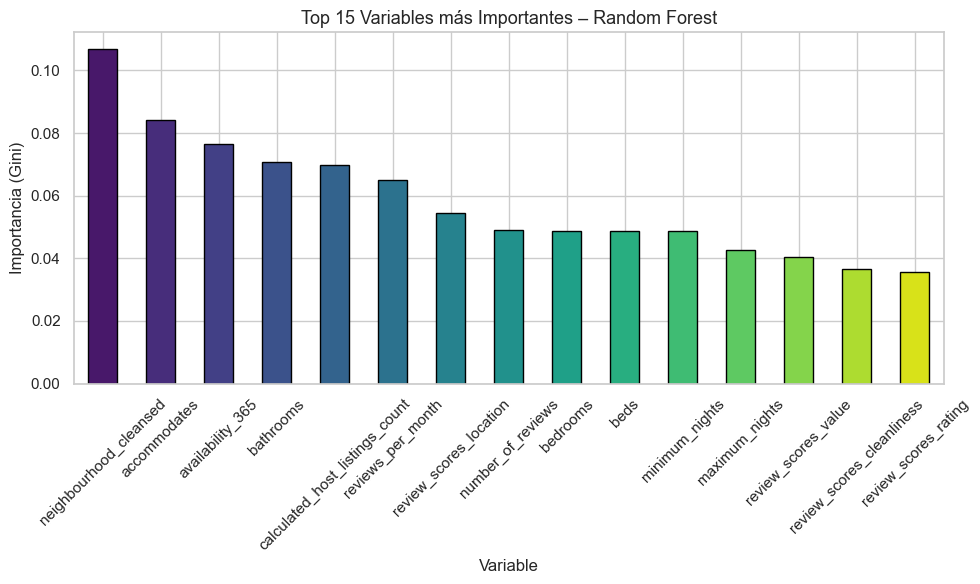


Top 10 variables más importantes:
neighbourhood_cleansed            0.1068
accommodates                      0.0842
availability_365                  0.0766
bathrooms                         0.0707
calculated_host_listings_count    0.0699
reviews_per_month                 0.0651
review_scores_location            0.0543
number_of_reviews                 0.0491
bedrooms                          0.0489
beds                              0.0488
dtype: float64


In [70]:
importancias = pd.Series(
    rf_base.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

top_n = 15
fig, ax = plt.subplots(figsize=(10, 6))
importancias.head(top_n).plot(
    kind='bar', ax=ax,
    color=sns.color_palette('viridis', top_n),
    edgecolor='black'
)
ax.set_title(f'Top {top_n} Variables más Importantes – Random Forest', fontsize=13)
ax.set_xlabel('Variable')
ax.set_ylabel('Importancia (Gini)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('importancia_variables_rf.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nTop 10 variables más importantes:')
print(importancias.head(10).round(4))

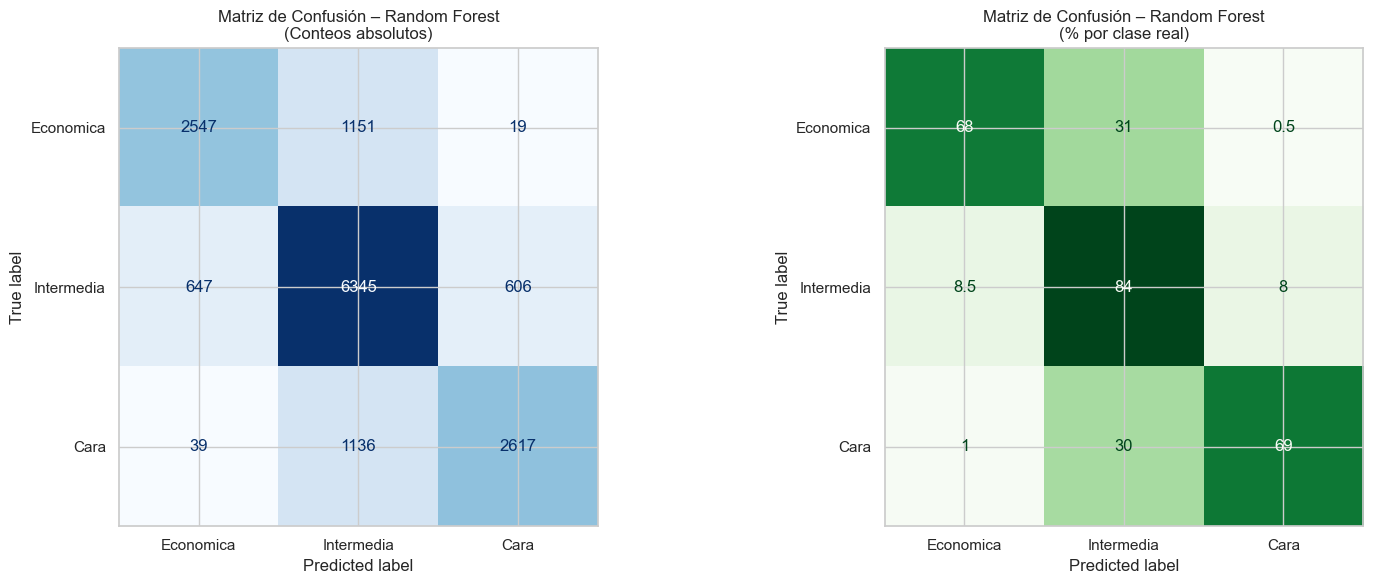

In [71]:
cm_rf = confusion_matrix(y_test_c, y_pred_rf, labels=orden_presente)
cm_rf_pct = cm_rf.astype(float) / cm_rf.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(cm_rf, display_labels=orden_presente).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión – Random Forest\n(Conteos absolutos)')

ConfusionMatrixDisplay(cm_rf_pct.round(1), display_labels=orden_presente).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz de Confusión – Random Forest\n(% por clase real)')

plt.tight_layout()
plt.savefig('matriz_confusion_rf.png', dpi=120, bbox_inches='tight')
plt.show()

In [72]:
configs_rf = [
    {'n_estimators': 50,  'max_depth': None},
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': None},
    {'n_estimators': 100, 'max_depth': mejor_profundidad},
    {'n_estimators': 200, 'max_depth': mejor_profundidad},
]

resultados_rf = []
for cfg in configs_rf:
    rf_tmp = RandomForestClassifier(
        n_estimators=cfg['n_estimators'],
        max_depth=cfg['max_depth'],
        random_state=42, n_jobs=-1
    )
    rf_tmp.fit(X_train_c, y_train_c)
    acc_t = accuracy_score(y_test_c, rf_tmp.predict(X_test_c))
    cv_t  = cross_val_score(
        rf_tmp, X_clf, y_clf,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='accuracy', n_jobs=-1
    ).mean()
    etiq_d = str(cfg['max_depth']) if cfg['max_depth'] else 'Sin límite'
    resultados_rf.append({
        'n_estimators': cfg['n_estimators'],
        'max_depth'   : etiq_d,
        'acc_test'    : round(acc_t, 4),
        'acc_cv_5fold': round(cv_t,  4)
    })

df_rf_comp = pd.DataFrame(resultados_rf)
print(' Comparación de configuraciones de Random Forest ')
print(df_rf_comp.to_string(index=False))

 Comparación de configuraciones de Random Forest 
 n_estimators  max_depth  acc_test  acc_cv_5fold
           50 Sin límite    0.7611        0.7617
          100 Sin límite    0.7618        0.7647
          200 Sin límite    0.7643        0.7671
          100         15    0.7510        0.7554
          200         15    0.7515        0.7560


In [73]:
# CV del mejor árbol individual
cv_mejor_arbol = cross_val_score(
    clf_mejor, X_clf, y_clf,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1
).mean()

# Mejor Random Forest
mejor_rf_fila = df_rf_comp.loc[df_rf_comp['acc_cv_5fold'].idxmax()]
mejor_rf = RandomForestClassifier(
    n_estimators=int(mejor_rf_fila['n_estimators']),
    max_depth=(None if mejor_rf_fila['max_depth'] == 'Sin límite'
               else int(mejor_rf_fila['max_depth'])),
    random_state=42, n_jobs=-1
)
mejor_rf.fit(X_train_c, y_train_c)
acc_mejor_rf = accuracy_score(y_test_c, mejor_rf.predict(X_test_c))

tabla_final = pd.DataFrame([
    {
        'Algoritmo'    : 'Árbol Base (sin poda)',
        'Acc Test'     : acc_base,
        'Acc CV-5'     : cv_scores.mean()
    },
    {
        'Algoritmo'    : f'Árbol Óptimo (prof={mejor_profundidad})',
        'Acc Test'     : acc_mejor,
        'Acc CV-5'     : cv_mejor_arbol
    },
    {
        'Algoritmo'    : f"Random Forest ({mejor_rf_fila['n_estimators']} árboles, prof={mejor_rf_fila['max_depth']})",
        'Acc Test'     : acc_mejor_rf,
        'Acc CV-5'     : mejor_rf_fila['acc_cv_5fold']
    }
])

tabla_final[['Acc Test', 'Acc CV-5']] = tabla_final[['Acc Test', 'Acc CV-5']].round(4)
print('COMPARACIÓN FINAL DE ALGORITMOS DE CLASIFICACIÓN ')
print(tabla_final.to_string(index=False))

COMPARACIÓN FINAL DE ALGORITMOS DE CLASIFICACIÓN 
                                   Algoritmo  Acc Test  Acc CV-5
                       Árbol Base (sin poda)    0.6828    0.6768
                      Árbol Óptimo (prof=15)    0.7126    0.7054
Random Forest (200 árboles, prof=Sin límite)    0.7643    0.7671


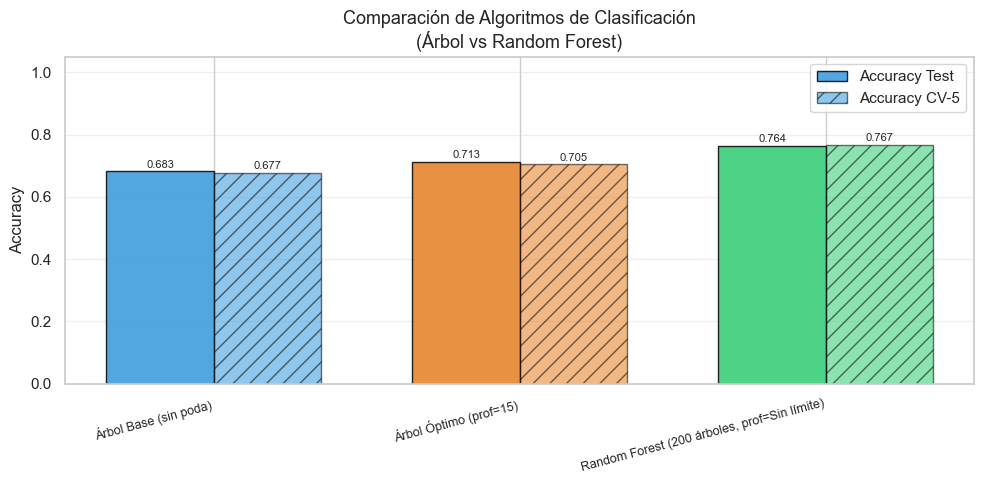

In [74]:
# Gráfica comparativa final 
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(tabla_final))
width = 0.35
colores = ['#3498db', '#e67e22', '#2ecc71']

bars1 = ax.bar(x - width/2, tabla_final['Acc Test'],  width,
               label='Accuracy Test', color=colores, edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, tabla_final['Acc CV-5'],  width,
               label='Accuracy CV-5', color=colores, edgecolor='black', alpha=0.55,
               hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(tabla_final['Algoritmo'], rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Comparación de Algoritmos de Clasificación\n(Árbol vs Random Forest)', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Etiquetas de valor
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('comparacion_final_algoritmos.png', dpi=120, bbox_inches='tight')
plt.show()